# Problem: Max of List, April 2026

In [5]:
%config InlineBackend.figure_format = 'retina'

import json, importlib
from pathlib import Path

import torch
import matplotlib.pyplot as plt
from nnsight import NNsight
from huggingface_hub import hf_hub_download

device = "cuda" if torch.cuda.is_available() else "cpu"
device = "mps" if torch.mps.is_available() else "cpu"
print(f"Using device: {device}")

# Download model definition and both sets of weights from HuggingFace
model_py_path = hf_hub_download("andyrdt/04_2026_puzzle_1a", "model.py")
spec = importlib.util.spec_from_file_location("model", model_py_path)
model_module = importlib.util.module_from_spec(spec)
spec.loader.exec_module(model_module)
AttentionOnlyTransformer = model_module.AttentionOnlyTransformer

# Pre-download both models so later cells don't need network access
config_1_path = hf_hub_download("andyrdt/04_2026_puzzle_1a", "config.json")
weights_1_path = hf_hub_download("andyrdt/04_2026_puzzle_1a", "model.pt")
config_2_path = hf_hub_download("andyrdt/04_2026_puzzle_1b", "config.json")
weights_2_path = hf_hub_download("andyrdt/04_2026_puzzle_1b", "model.pt")

print("Downloaded model definition + weights for both models.")



Using device: mps
Downloaded model definition + weights for both models.


In [6]:
# ── Model 1 vocab (numbers 0-9, each is its own token) ──
NUM_RANGE_1 = 10
BOS_1, SEP_1, ANS_1, EOS_1 = 10, 11, 12, 13
VOCAB_SIZE_1 = 14
TOKEN_NAMES_1 = {10: "BOS", 11: "SEP", 12: "ANS", 13: "EOS"}

def tokenize_1(nums: list[int]) -> list[int]:
    """Tokenize a list of numbers for Model 1.
    Example: [3, 7, 2] -> [BOS, 3, SEP, 7, SEP, 2, ANS]"""
    tokens = [BOS_1]
    for i, n in enumerate(nums):
        tokens.append(n)
        if i < len(nums) - 1:
            tokens.append(SEP_1)
    tokens.append(ANS_1)
    return tokens

def token_labels_1(tokens: list[int]) -> list[str]:
    return [TOKEN_NAMES_1.get(t, str(t)) for t in tokens]


# ── Model 2 vocab (digits 0-9, two per number) ──
BOS_2, SEP_2, ANS_2, EOS_2 = 10, 11, 12, 13
VOCAB_SIZE_2 = 14
TOKEN_NAMES_2 = {10: "BOS", 11: "SEP", 12: "ANS", 13: "EOS"}

def tokenize_2(nums: list[int]) -> list[int]:
    """Tokenize a list of numbers for Model 2.
    Example: [42, 7, 85] -> [BOS, 4, 2, SEP, 0, 7, SEP, 8, 5, ANS]"""
    tokens = [BOS_2]
    for i, n in enumerate(nums):
        tokens.append(n // 10)
        tokens.append(n % 10)
        if i < len(nums) - 1:
            tokens.append(SEP_2)
    tokens.append(ANS_2)
    return tokens

def token_labels_2(tokens: list[int]) -> list[str]:
    return [TOKEN_NAMES_2.get(t, str(t)) for t in tokens]


# ── Attention visualization ──
def _format_attn_ax(ax, attn_matrix, token_labels, title):
    """Format a single attention heatmap axis."""
    ax.imshow(attn_matrix, cmap="Blues", vmin=0, vmax=1)
    ax.set_xticks(range(len(token_labels)))
    ax.set_xticklabels(token_labels, rotation=45, ha="right",
                       rotation_mode="anchor", fontsize=7)
    ax.set_yticks(range(len(token_labels)))
    ax.set_yticklabels(token_labels, fontsize=7)
    ax.set_title(title, fontsize=10)


def plot_attention(attn_patterns, token_labels, title="Attention"):
    """Plot attention heatmaps.

    Args:
        attn_patterns: tensor of shape (n_heads, seq, seq) or list of such tensors
                       (one per layer).
        token_labels: list of strings for tick labels.
        title: plot title.
    """
    if isinstance(attn_patterns, list):
        n_layers = len(attn_patterns)
        n_heads = attn_patterns[0].shape[0]
        fig, axes = plt.subplots(n_layers, n_heads, figsize=(4 * n_heads, 3.5 * n_layers))
        if n_layers == 1:
            axes = [axes]
        for layer_idx in range(n_layers):
            attn = attn_patterns[layer_idx].detach().cpu().numpy()
            for h in range(n_heads):
                _format_attn_ax(axes[layer_idx][h], attn[h], token_labels,
                                f"L{layer_idx}H{h}")
    else:
        attn = attn_patterns.detach().cpu().numpy()
        n_heads = attn.shape[0]
        fig, axes = plt.subplots(1, n_heads, figsize=(4 * n_heads, 3.5))
        if n_heads == 1:
            axes = [axes]
        for h in range(n_heads):
            _format_attn_ax(axes[h], attn[h], token_labels, f"H{h}")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

print("Helpers loaded.")

Helpers loaded.


In [7]:
# Load Model 1
config_1 = json.loads(Path(config_1_path).read_text())
raw_model_1 = AttentionOnlyTransformer.from_config(config_1["model"])
raw_model_1.load_state_dict(torch.load(weights_1_path, map_location=device, weights_only=True))
raw_model_1.eval().to(device)
# `NNsight` wraps the model for tracing/interventions, but still exposes the
# underlying module tree and parameters for normal inspection.
model_1 = NNsight(raw_model_1)

print(f"Model 1 config: {config_1['model']}")
print(f"Parameters: {sum(p.numel() for p in model_1.parameters()):,}") #12*64+2*14*64+64^2+3*64^2

Model 1 config: {'vocab_size': 14, 'd_model': 64, 'n_heads': 4, 'n_layers': 1, 'max_seq_len': 12}
Parameters: 18,944


# Overview

In this notebook I will attempt to understand simple attention-only transformers based on https://puzzles.baulab.info/april-2026.html.

The goal for the challenge is stated as: 

*Given a list of numbers, predict the maximum. We have two models of varying complexity, both attention-only transformers trained to 100% accuracy. Your goal: reverse-engineer the algorithm each model has learned.*

The two models are:

- Model 1a: each number (0–9) gets its own token, and the model is just a single attention layer.
- Model 1b: numbers range from 0–99, but each number is tokenized as two separate digits (tens and ones). The model has two attention layers and must first figure out how to somehow combine the information from both digits.

In the first part I will explain my attempt for Model 1a. Then, I will go to Model 1b.

##### What this is and is not

We try to identify the mechanism the model uses to solve the task and verify each component through ablations and circuit-level analysis. It is not a quantitative mechanistic estimate of the model's accuracy from its weights. 

The puzzle asked to reverse-engineer the algorithm, which I interpret as identifying and naming the components and their interactions, and that is what I have done here.

## Recap

Model 1a takes a list of five digits in $\{0, \ldots, 9\}$ and outputs the maximum. Below is an algorithm I extracted, in the order in which the model executes it.

1. **The QK circuit selects the position of the largest digit.** The query at the ANS position produces a pre-softmax score $f_h(d)$ against each digit $d$, and for heads H0, H2, H3 this score is monotonically increasing in $d$. H3 learns a smooth, roughly cosine-shaped score (or inverted sigmoid too); H0 and H2 learn step functions with thresholds around $d \approx 6$. Since a sum of monotonically increasing functions is itself monotonically increasing,
$$\text{score}(d) = \sum_h f_h(d)$$
is monotonic in $d$, and the softmax concentrates attention on the position holding the largest digit.

2. **The OV circuit writes a logit pattern peaked at that digit.** Each head's OV circuit $W_U W_O^h W_V^h W_E$ (restricted to the ten digit tokens) is rank-1, so no single head can copy the attended digit. The combined effect across heads still produces the correct logits; the rank-1 SVD gives, for each head, a read direction $v_1^h$, a write direction $u_1^h$, and a singular value $\sigma_h$. So when ANS attends to digit $d$, head $h$ contributes
$$\sigma_h \cdot v_1^h(d) \cdot u_1^h$$
to the logits.

The interesting empirical fact is that **the read directions are shared across H0, H2, H3** (pairwise cosine similarities $\approx 1.00$), while the write directions are not (cosines between $0.44$ and $0.87$). All three heads read the same scalar magnitude feature of the attended digit, then project it onto distinct logit-space directions weighted by $\sigma_h \in \{168, 218, 809\}$. The total logit contribution simplifies to
$$\text{logits}(d) = f(d) \sum_h \sigma_h \, u_1^h,$$
where $f(d)$ is a single shared scalar function and $\sum_h \sigma_h u_1^h$ is a fixed 10-dimensional pattern whose argmax coincides with the input digit. The model implements digit identification not by copying but by combining overlapping threshold votes through a shared scalar readout.

These are the main findings. I also write below a couple of details that would have been worth investigating more if I had more time. 

##### The role of H1

H1 sits outside the H0/H2/H3 cluster. Its QK is anti-aligned with H3 (cosine $-0.34$), its OV write direction is anti-aligned with the main heads, and its singular value $\sigma_{H1} = 48$ is much smaller than the others. Its attention to number positions is on the order of $10^{-13}$, so its QK circuit is dormant in practice. Empirically, removing H1 leaves accuracy at $100\%$ except on the input $[8,8,8,8,8]$, where the other three heads produce a near-tie between digits $8$ and $9$. H1 contributes a small fixed bias whose anti-correlated sign breaks the tie.

##### The direct path and self-attention sinks

The direct path $W_U(W_E[\text{ANS}] + W_P[10])$ writes a small input-independent bias toward digit $7$, matching the statistical prior over the maximum of five i.i.d. uniform digits. This bias is wrong on edge cases like all-zeros input. The self-attention sinks correct it: when no number activates the QK circuit strongly, heads default to attending on ANS itself, and the OV outputs from ANS-to-ANS attention contribute fixed logits that swamp the direct path. For the input $[0,0,0,0,0]$, H3's self-attention bias alone writes $+300$ to logit $0$, overpowering the direct path's $+2.3$ on logit $7$.

## Model 1a

Model 1a looks simple: just take a list of five digits `[a, b, c, d, e]`, and give us the maximum. But how does it do this? To answer this question, we are going to directly inspect some parts of the model.

### Gaining a general idea of the problem

Model 1a is schematically represented in Figure 1.

<div align="center">
  <img src="plots/model_1a_general_prev.jpg" alt="Model 1a Schematic" width="300px">
  <p><b>Figure 1:</b> Schematic representation of Model 1a.</p>
</div>

The model takes a list of input tokens, such as one token $\vec{t}$ from possible, their positions, and embeds them in a big dimensional space of size $d_{\mathrm{model}}=64$. 

At the end of the model, we apply the linear operation $W_U$ to bring it back into token space through $W_U \vec{x}^{(1)}$. The token space is based on our vocabulary of size $d_{\mathrm{vocab}}=14$. This has numbers, such as 9 or 4, as well as special tokens, such as `BOS` or `ANS`.

In our case `ANS` is the answer token, to which we are going to write the answer. It then seems natural to forget about everything else, and just focus on how does the model manage to give us the answer at the position of `ANS`? This is what we are going to focus here. We do not need to understand everything. But just make a definite question, and try to have a definite answer (and iteratively refine our understanding).

### Looking at the specifics of the attention layer

Ok. We now that we need to focus on the `ANS`. At least this is our route. But how does `ANS` get an answer? In particular, for our case how does it get *the* answer.

To guide us towards this, let's look at how $W_U \vec{x}^{(1)}$ is obtained.

Our attention layer is composed by four attention heads $h_a, a \in \{0, 1, 2, 3\}$. The $d_{\mathrm{model}}=64$ dimension is broken into four spaces each of dimension $d_{\mathrm{head}}=64/4=16$. Hence, each attention head will take $\vec{x}^{(0)}_i$ of dimension $d_{\mathrm{model}}$, and port it into a smaller space.

A specific output token is given by:

$$\vec{x}^{(1)}_i = \vec{x}^{(0)}+\sum_{h \in H_1} h(\vec{x}^{(0)})\ ,$$

where $H_1$ contains the attention heads at layer 1, each acting on the current residual stream.

Figure 2 shows an example of an attention head, operating on a sequence of inputs.

<div align="center">
  <img src="plots/one_head_model.jpg" alt="Attention Head Schematic" width="300px">
  <p><b>Figure 2:</b> Schematic representation of an attention head</p>
</div>

The most important point for us is that the output of one single attention head at some specific postion is basically a weighted sum of vectors coming from the other tokens. In our case, these tokens are directly the ones coming from the input list of numbers. As an example, the `ANS` token will be something like:

$$h(\vec{x}_{\mathrm{ANS}}^{(0)}) = \sum_i w_{\mathrm{ANS}i} \vec{z}_i\ ,$$

where $\vec{z}_i$ are just other tokens. The most important point is that the token answer is a weighted sum of other digits. If `ANS` is going to give us the true maximum, this means that the corresponding weight has to be high enough to dominate over the other digits.

Well, reality is not as simple, as our final output is actually a sum over the heads, not just a result of a single head. But we want to make incremental progress. So, we are going with whatever we have and see if it makes sense or not. Then, if it turns out it does not make sense, we can always change our approach. Hence, our second hypothesis is the following: **by looking at which elements have the highest weights, we can have an idea of where the max token is.**

Ok. Now that we have an idea of what we want to do, let's do quick emprical tests to see where we can go.

Note that this 1-layer attention transformer can be decomposed into an attention independent part leading to a constant bias (number 7), plus the attention dependent part. The latter is more important than the former, in this case. So, we will focus on this.

## What do attention heads focus on?

The matrix $A_{ij}$ has dimensions $N\times N$: it looks at a token at row $i$, then scans over the previous tokens at rows $j \leq i$ to see how these affect our current token at position $i$.

Obviously, we will focus most of our energies on the last token, as this is where the answer should be written. 

So, our hypothesis is that the ANS token at the last position should attend the most at the maximum digit. Let's see if we can refute this.

To validate this idea, we run a bunch of samples, each example with its own max. We then plot the attention for each head to see what is happening.

In the plot below, each row has the maximum at some specific position, as averaging over all max positions blurs the signal.

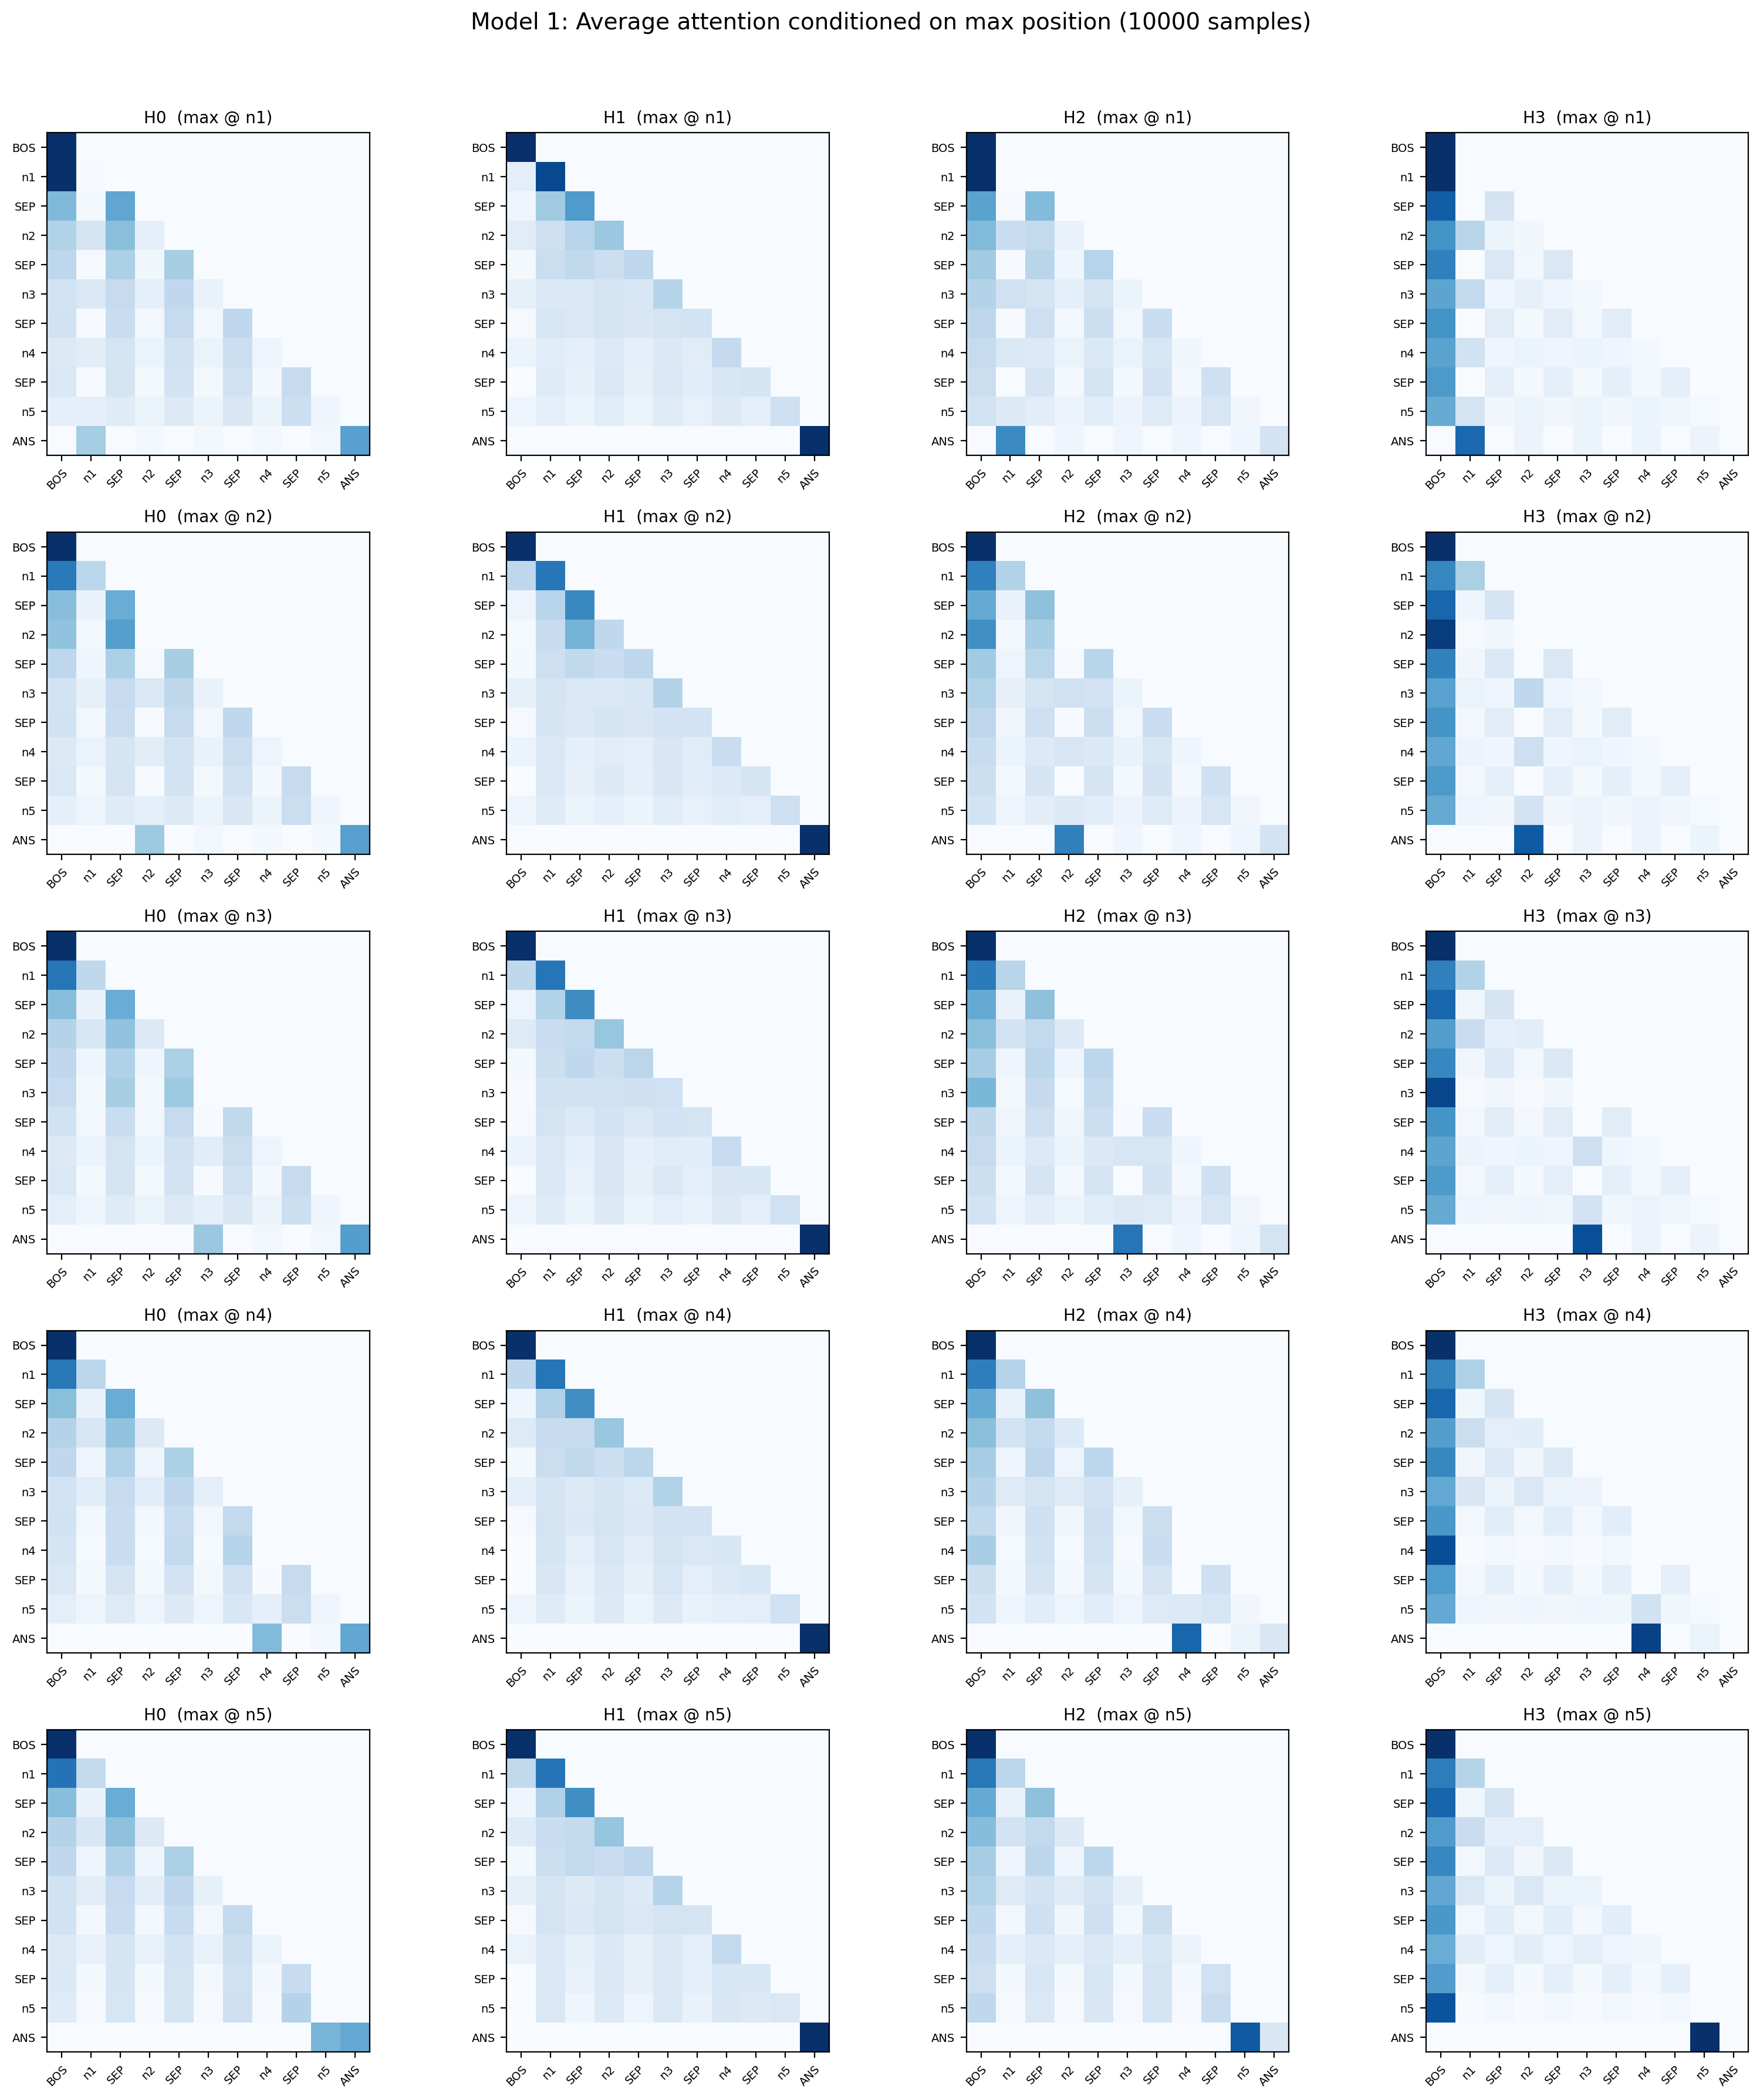

In [8]:
import numpy as np                                                     
                                                                        
# Average attention patterns conditioned on which position holds the max                                                                
N_SAMPLES = 10000       
rng = np.random.default_rng(42)                                        
n_positions = 5                                            

# Collect per-position averages for heatmaps + raw data for scatter plots
accum = {pos: None for pos in range(n_positions)}
counts = {pos: 0 for pos in range(n_positions)}
scatter_data = {pos: [] for pos in range(n_positions)}  # (nums,attn_ANS_row)

for _ in range(N_SAMPLES):
    nums = rng.integers(0, NUM_RANGE_1, size=5).tolist()
    max_pos = nums.index(max(nums))

    tokens = tokenize_1(nums)
    x = torch.tensor([tokens], device=device)
    with torch.no_grad():
        _, attn_patterns = model_1(x)

    attn = attn_patterns[0][0].detach().cpu()  # (n_heads, seq,seq)
    if accum[max_pos] is None:
        accum[max_pos] = attn.clone()
    else:
        accum[max_pos] += attn
    counts[max_pos] += 1
    # Store ANS row attention to number positions (indices 1,3,5,7,9) per head
    scatter_data[max_pos].append((nums, attn[:, -1, 1::2].numpy()))

# ── Heatmaps: 5 rows (max position) × 4 columns (head) ──
n_heads = 4
fig, axes = plt.subplots(n_positions, n_heads, figsize=(4 * n_heads, 3.5 * n_positions))
generic_labels = ["BOS", "n1", "SEP", "n2", "SEP", "n3", "SEP", "n4", "SEP", "n5", "ANS"]

for pos in range(n_positions):
    avg = (accum[pos] / counts[pos]).numpy()
    for h in range(n_heads):
        _format_attn_ax(axes[pos][h], avg[h], generic_labels,f"H{h}  (max @ n{pos+1})")

fig.suptitle(f"Model 1: Average attention conditioned on max position ({N_SAMPLES} samples)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

The results look interesting! We can see that when max is at position $n_i$, the `ANS` row lightens at that position!

Observations:

- head 2 and head 3 have `ANS` attending to the maximum.
- head 0 also looks at the maximum for the `ANS`, and `ANS` self-attends. 
- head 1 has `ANS` self-attending. But by eye it looks like there is no other interesting behaviour.
- head 2 is similar to Head 0.

One note: head 3 has `ANS` attending at the maximum. But, it looks like every token except `ANS` looks at `BOS`. Why? This might be an attention sink, where we allocate attention to some harmless token, usually the first token. This allows to satisfy the softmax constraints. Given the time, we are not going to explore this.

And what about Head 1? What is happening here? Could it be a plotting artifact? Let's plot 1-dimensional plots of the `ANS`row.

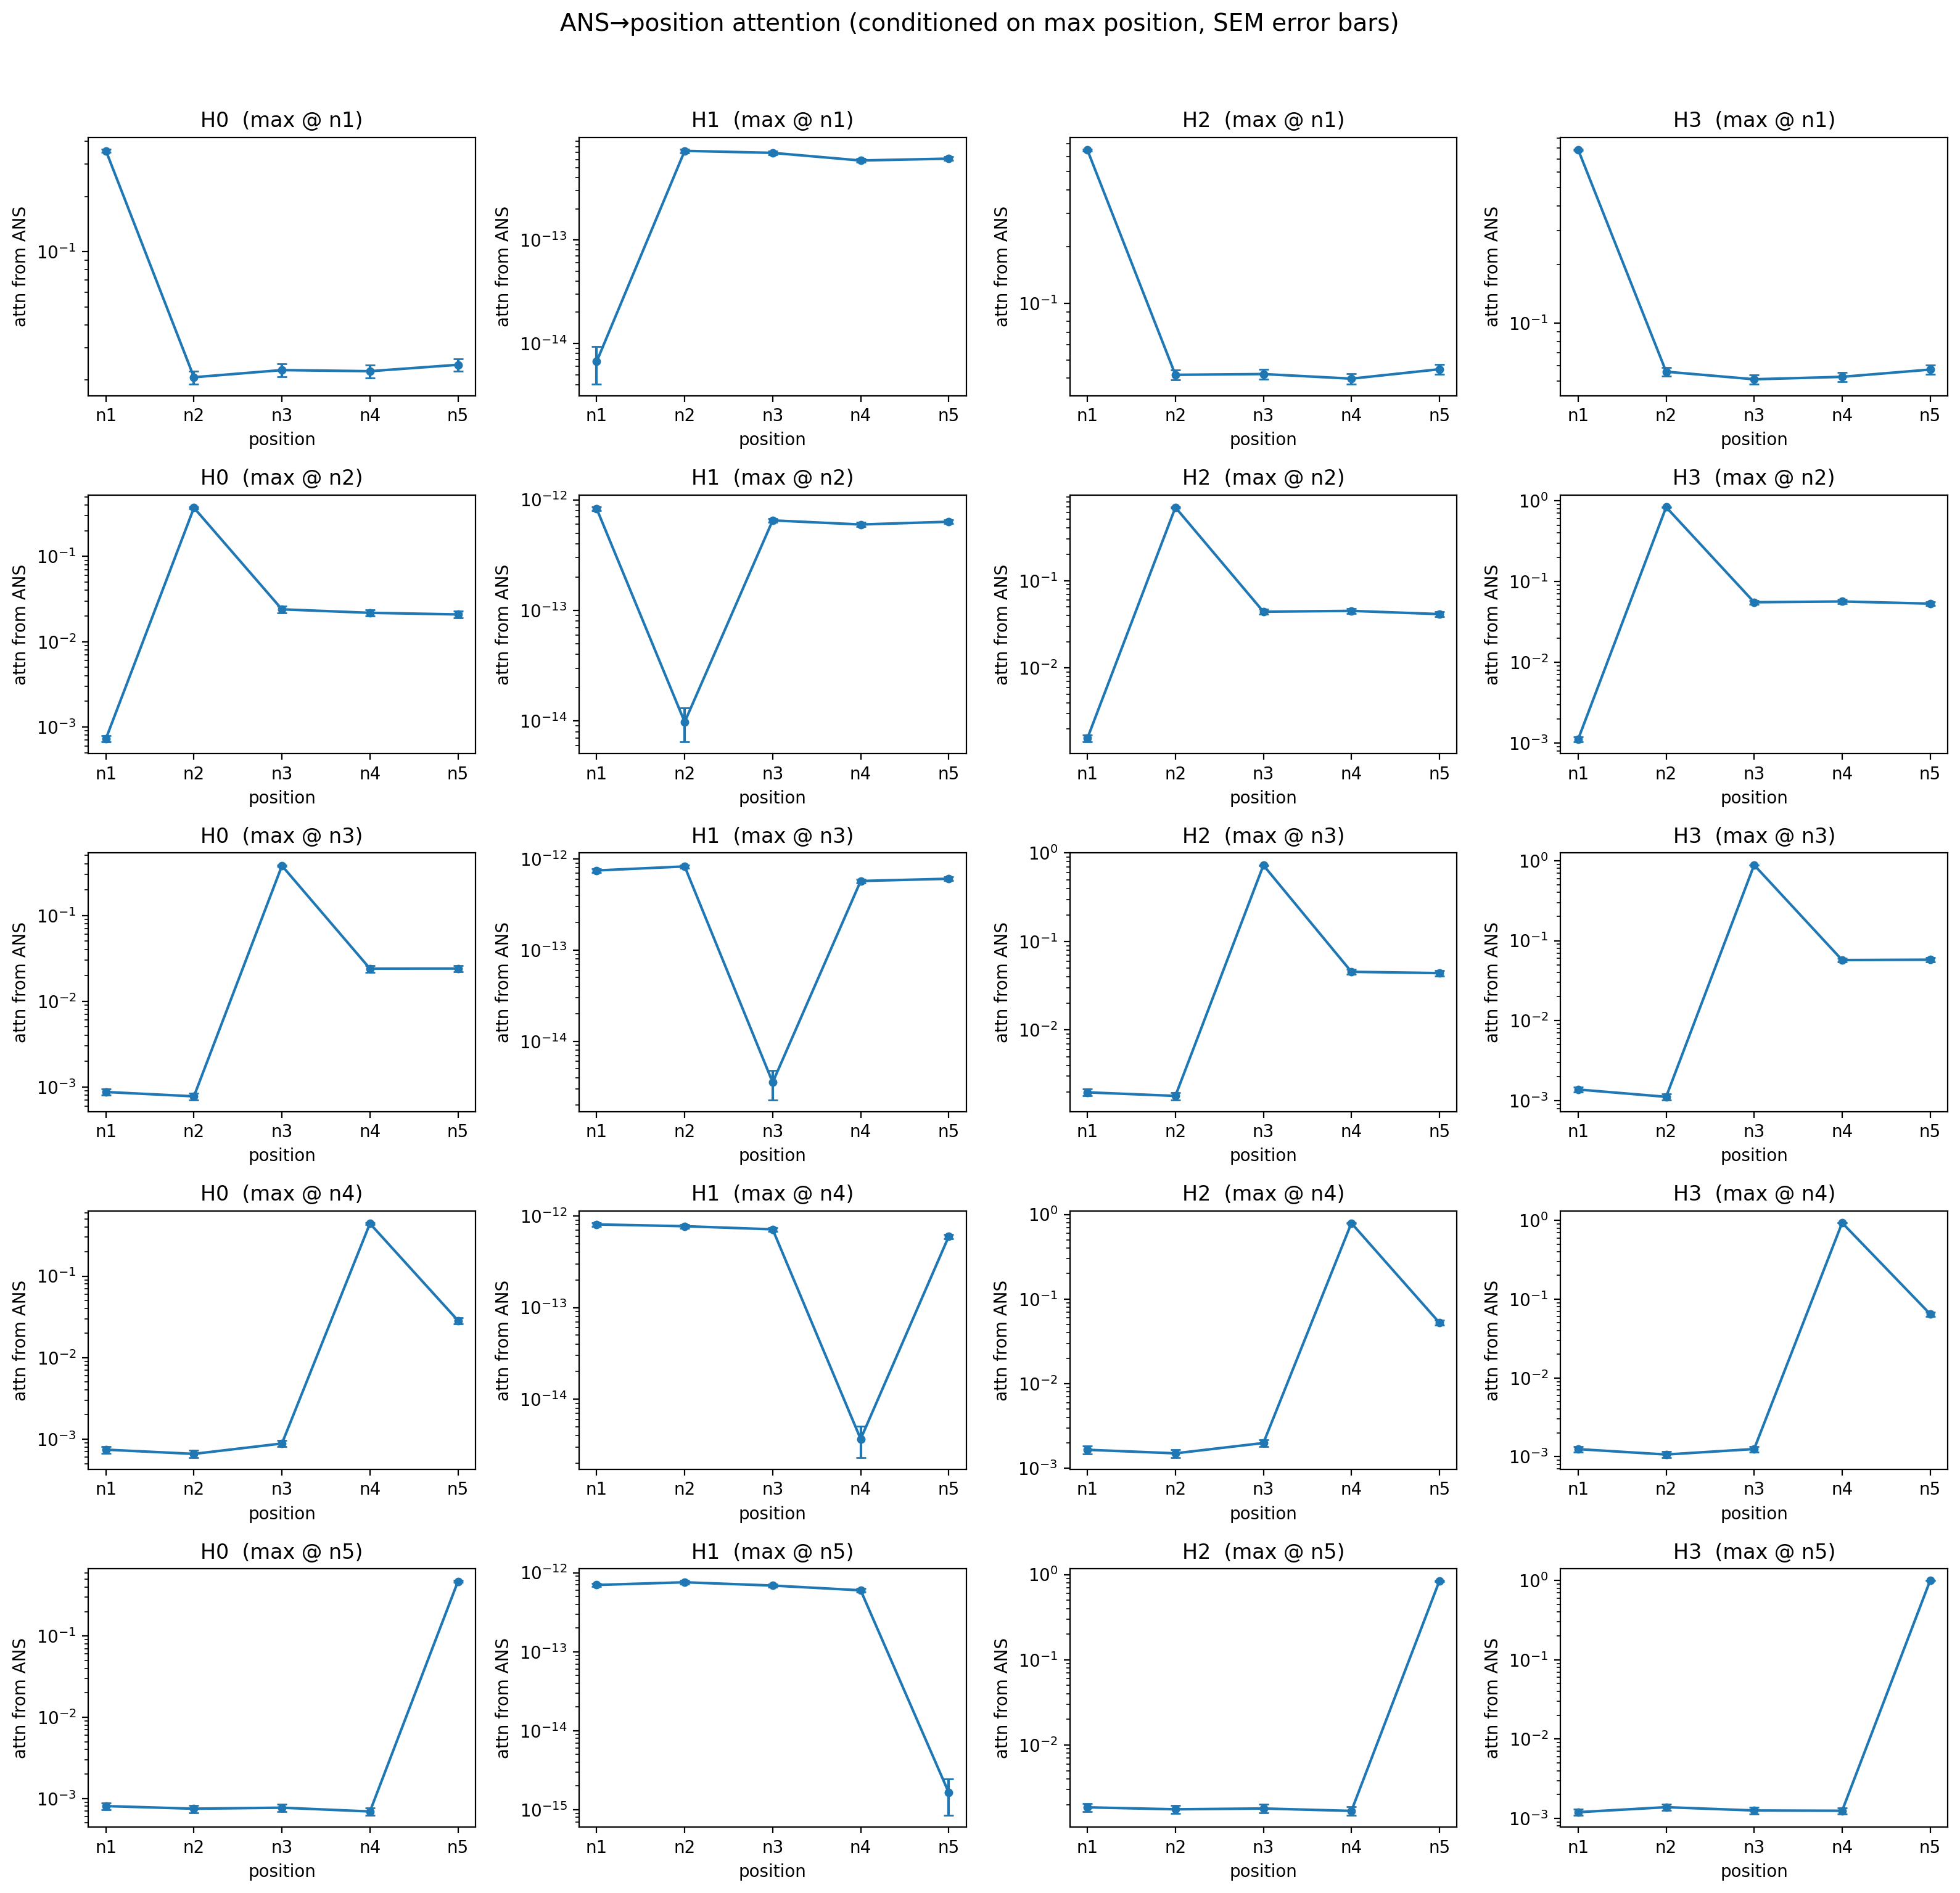

In [9]:
# ── ANS attention vs position with SEM error bars, conditioned on max position ──                                                                                 
fig, axes = plt.subplots(n_positions, n_heads, figsize=(4 * n_heads, 3 * n_positions))                                                                        
pos_labels = ["n1", "n2", "n3", "n4", "n5"]                                          

for pos in range(n_positions):                                                       
        for h in range(n_heads):                                                       
                all_attn = np.array([attn_ans[h] for _, attn_ans in scatter_data[pos]])      # (N, 5)
                means = all_attn.mean(axis=0)
                sems = all_attn.std(axis=0) / np.sqrt(all_attn.shape[0])

                axes[pos][h].errorbar(range(5), means, yerr=sems, fmt='o-', capsize=3,markersize=4)
                axes[pos][h].set_xticks(range(5))
                axes[pos][h].set_xticklabels(pos_labels)
                axes[pos][h].set_title(f"H{h}  (max @ n{pos+1})")
                axes[pos][h].set_xlabel("position")
                axes[pos][h].set_ylabel("attn from ANS")
                axes[pos][h].set_yscale("log")

fig.suptitle("ANS→position attention (conditioned on max position, SEM error bars)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

##### Ok. Something is happening. H1 is always the smallest at the maximum. While the other heads clearly see a big attention on the maximum.

Look also at the scales. We see that head 1 is of the order $10^{-15}-10^{-12}$! Where is the attention going to Head 1? As we saw earlier, all to the `ANS` token.

Which role does H1 have then? One could argue that perhaps other components of H1 play some relevant role. But given the size of this model and that we have access to its weights, the quickest way to verify H1 role is by removing it.

Let's therefore generate a random list of 1000 numbers and see what happens.

In [10]:
WE = raw_model_1.state_dict()["tok_embed.weight"]
WP = raw_model_1.state_dict()["pos_embed.weight"]
WU = raw_model_1.state_dict()["unembed.weight"]
WO = raw_model_1.state_dict()["layers.0.W_O.weight"]


import random
random.seed(42)

Nnumbers = 1000

# Generate many test cases
test_inputs = []                                                                      
for _ in range(Nnumbers):                                                                  
    nums = [random.randint(0, 9) for _ in range(5)]
    test_inputs.append(nums)                                                          
                                                                                    
def accuracy_with_ablation(test_inputs, ablated_heads):                                            
    """Run model with specified heads zeroed out, return accuracy."""
    correct = 0                                                                       
    for nums in test_inputs:                                                       
        tokens = tokenize_1(nums)                                                     
        x = torch.tensor([tokens], device=device)                                  
                                                                                    
        # Get embeddings                                        
        positions = torch.arange(len(tokens), device=device).unsqueeze(0)             
        x_embed = WE[x[0]] + WP[positions[0]]  # [seq, 64]                            
                                                                                    
        # Direct path                                                                 
        logits = WU @ x_embed[-1]  # [14]                                             
                                                                                    
        # Add non-ablated heads                                                       
        _, attn_patterns = raw_model_1(x)
        attn = attn_patterns[0][0]                                                    
        for h in range(4):                                      
            if h in ablated_heads:                                                    
                continue                                        
            W_V_h = raw_model_1.layers[0].heads[h].W_V.weight               
            W_O_h = WO[:, h*16:(h+1)*16]                                              
            values = x_embed @ W_V_h.T
            attn_ANS = attn[h, -1, :]                                                 
            weighted_v = attn_ANS @ values                                            
            logits += WU @ (W_O_h @ weighted_v)                                       
                                                                                    
        pred = logits[:NUM_RANGE_1].argmax().item()                                   
        if pred == max(nums):                                                         
            correct += 1                                                              
    return correct / len(test_inputs)                           

# Test all combinations                                                               
print(f"No ablation:        {accuracy_with_ablation(test_inputs, []):.1%}")
for h in range(4):                                                                    
    print(f"Remove head {h}:      {accuracy_with_ablation(test_inputs, [h]):.1%}")
print(f"Remove heads 0,2,3: {accuracy_with_ablation(test_inputs, [0,2,3]):.1%}")                   
print(f"Remove head 1 only: {accuracy_with_ablation(test_inputs, [1]):.1%}")     
print(f"Keep only head 0:   {accuracy_with_ablation(test_inputs, [1,2,3]):.1%}") 
print(f"Keep only head 1:   {accuracy_with_ablation(test_inputs, [0,2,3]):.1%}") 
print(f"Keep only head 2:   {accuracy_with_ablation(test_inputs, [0,1,3]):.1%}")                   
print(f"Keep only head 3:   {accuracy_with_ablation(test_inputs, [0,1,2]):.1%}") 

No ablation:        100.0%
Remove head 0:      35.8%
Remove head 1:      100.0%
Remove head 2:      51.4%
Remove head 3:      41.0%
Remove heads 0,2,3: 16.5%
Remove head 1 only: 100.0%
Keep only head 0:   41.3%
Keep only head 1:   16.5%
Keep only head 2:   40.6%
Keep only head 3:   8.7%


First, no head alone is good on its won. Second, removing head 0 brings to the largest degradation. But most importantly, removing head 1 does not lead to any degradation!

But are we sure? Note that we generated a random list of tokens, perhaps excluding some edge cases.

One obvious edge case we exclude is when all the numbers are the same. Lets' check again.

In [11]:
# Generate many test cases
test_inputs_1 = test_inputs.copy()

for i in range(0, 10):                                                                  
    nums = [i for _ in range(5)]
    test_inputs_1.append(nums)    
       
# Test all combinations                                                               
print(f"No ablation:        {accuracy_with_ablation(test_inputs_1, []):.1%}")
for h in range(4):                                                                    
    print(f"Remove head {h}:      {accuracy_with_ablation(test_inputs_1, [h]):.1%}")
print(f"Remove heads 0,2,3: {accuracy_with_ablation(test_inputs_1, [0,2,3]):.1%}")                   
print(f"Remove head 1 only: {accuracy_with_ablation(test_inputs_1, [1]):.1%}")                       
print(f"Keep only head 3:   {accuracy_with_ablation(test_inputs_1, [0,1,2]):.1%}") 

No ablation:        100.0%
Remove head 0:      36.0%
Remove head 1:      99.9%
Remove head 2:      51.4%
Remove head 3:      40.9%
Remove heads 0,2,3: 16.4%
Remove head 1 only: 99.9%
Keep only head 3:   8.8%


Oh. Ok. H1 is clearly doing something! I played a little bit with the equal lists of numbers, and it looks like something happens with number 8, while the rest of the numbers are fine. Let's check.

In [12]:
# Generate many test cases
# Generate many test cases
test_inputs_1 = test_inputs.copy()

for i in range(0, 10):        
    if i == 8:
        continue                                                
    nums = [i for _ in range(5)]
    test_inputs_1.append(nums)  
              
print("Result with [8, 8, 8, 8, 8] not in the list")
print(f"Remove head 1 only: {accuracy_with_ablation(test_inputs, [1]):.1%}")

print("Result with [8, 8, 8, 8, 8] in the list")
test_inputs.append([8]*5)
print(f"Remove head 1 only: {accuracy_with_ablation(test_inputs, [1]):.1%}")

Result with [8, 8, 8, 8, 8] not in the list
Remove head 1 only: 100.0%
Result with [8, 8, 8, 8, 8] in the list
Remove head 1 only: 99.9%


To see what is happening, let's plot something like the logits.

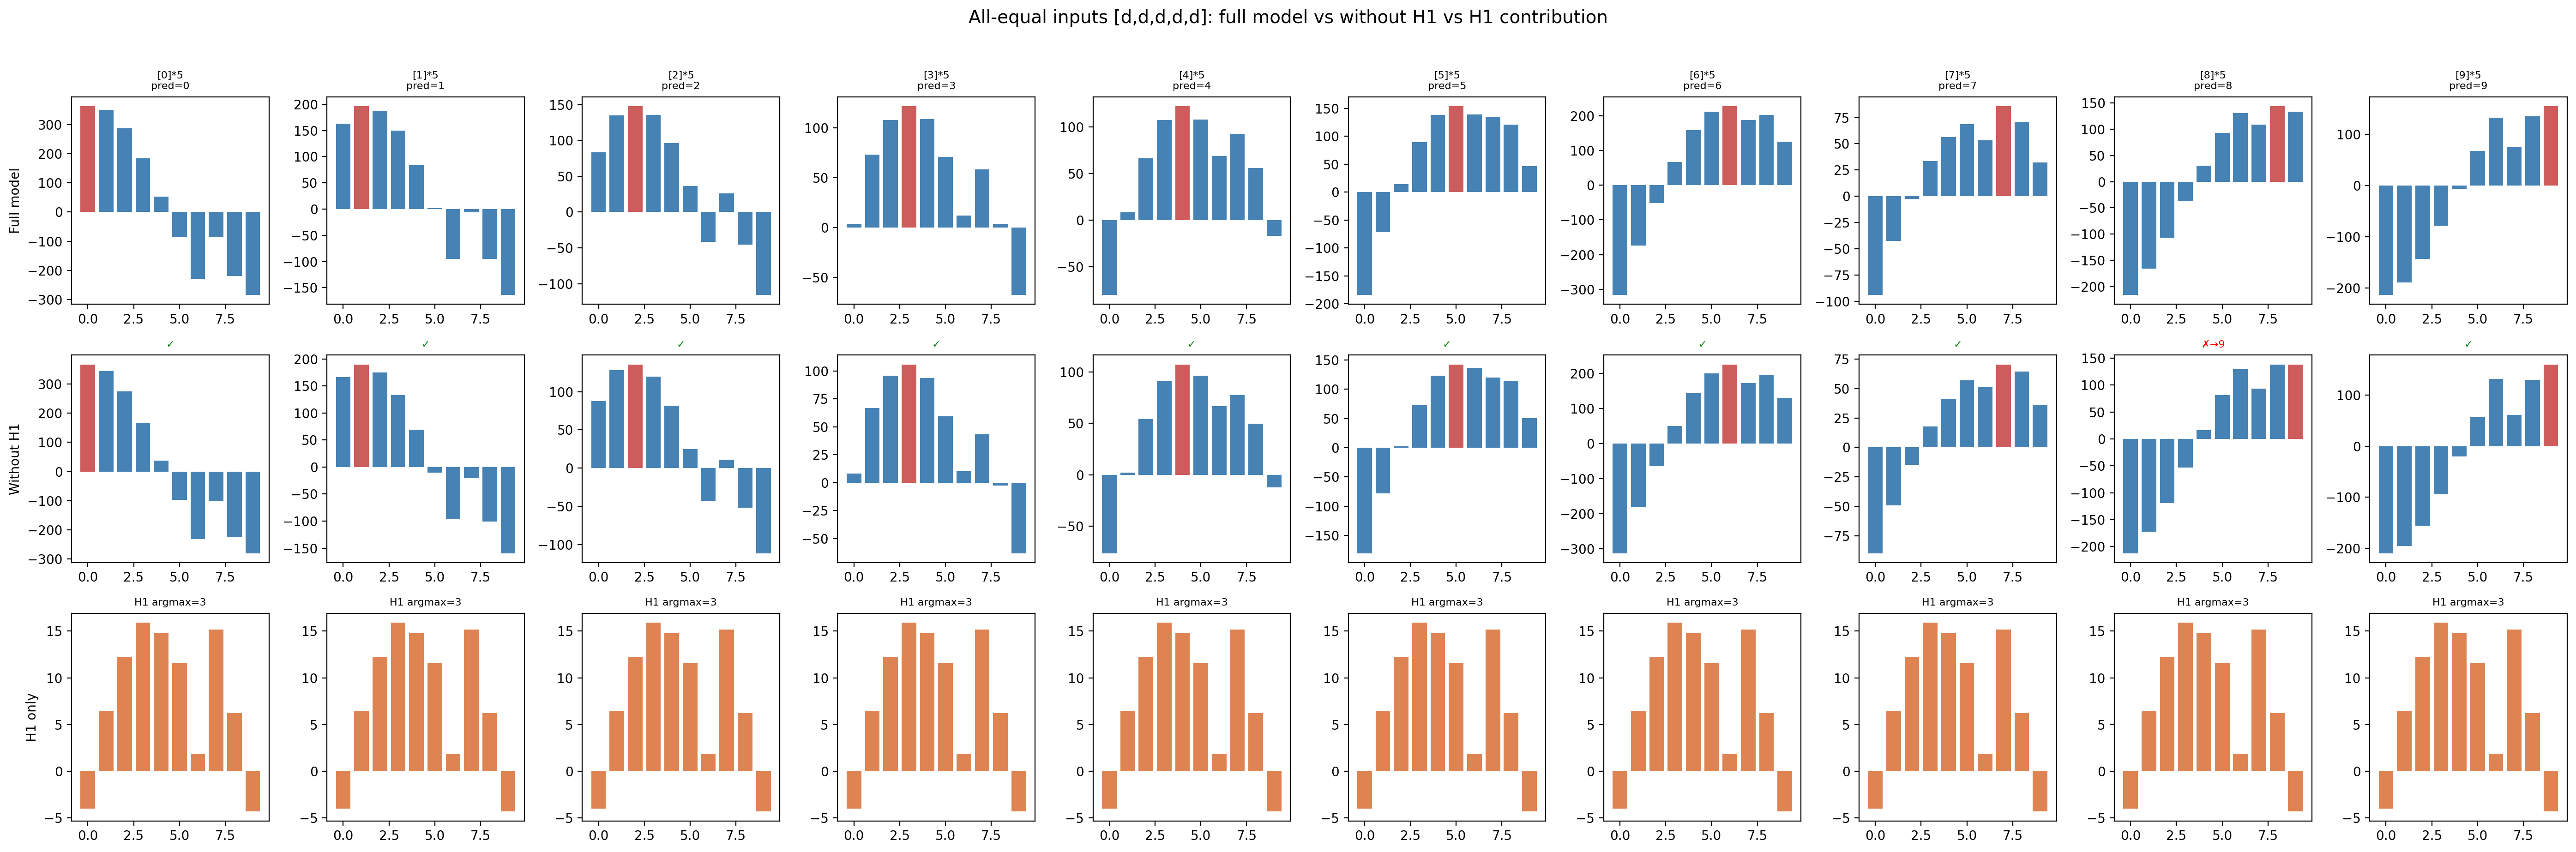

In [13]:
# ── Logit decomposition: what does each head contribute at the ANS position? ──
# In a 1-layer model: logits_ANS = W_U @ (x_ANS^0 + sum_h W_O_h @ r_h)
# Decomposes into: direct_path + head_0 + head_1 + head_2 + head_3

def decompose_logits(model, tokens, device):
    """Return per-component logits at the ANS position (last token)."""
    x = torch.tensor([tokens], device=device)
    b, s = x.shape
    positions = torch.arange(s, device=device).unsqueeze(0)

    x0 = model.tok_embed(x) + model.pos_embed(positions)  # (1, seq, d_model)
    mask = torch.tril(torch.ones(s, s, device=device)).unsqueeze(0)

    W_U = model.unembed.weight
    direct = W_U @ x0[0, -1]  # (vocab,)

    head_contribs = []
    W_O_full = model.layers[0].W_O.weight
    d_head = model.d_model // model.n_heads

    for h, head in enumerate(model.layers[0].heads):
        q = head.W_Q(x0)
        k = head.W_K(x0)
        v = head.W_V(x0)
        scores = torch.einsum('bid,bjd->bij', q, k) / (d_head ** 0.5)
        scores = scores.masked_fill(mask == 0, float('-inf'))
        attn = torch.softmax(scores, dim=-1)
        r_h = torch.einsum('j,jd->d', attn[0, -1], v[0])  # (1, d_head)

        W_O_h = W_O_full[:, h * d_head:(h + 1) * d_head]
        contrib = W_U @ W_O_h @ r_h.squeeze()
        head_contribs.append(contrib.detach())

    return direct.detach(), head_contribs


# ── Why does [8,8,8,8,8] specifically need H1? ──
# Decompose logits for all-equal inputs, with and without H1                         
                                                                                    
fig, axes = plt.subplots(3, 10, figsize=(28, 9))
                                                                                    
for digit in range(10):                                                            
    nums = [digit] * 5
    tokens = tokenize_1(nums)

    with torch.no_grad():
        direct, head_contribs = decompose_logits(raw_model_1, tokens, device)

    # Row 1: Full model (all heads)
    full = (direct + sum(head_contribs))[:NUM_RANGE_1].cpu().numpy()
    pred_full = full.argmax()
    colors = ['indianred' if i == pred_full else 'steelblue' for i in
range(NUM_RANGE_1)]
    axes[0][digit].bar(range(NUM_RANGE_1), full, color=colors)
    axes[0][digit].set_title(f"[{digit}]*5\npred={pred_full}", fontsize=8)
    if digit == 0:
        axes[0][digit].set_ylabel("Full model")

    # Row 2: Without H1
    no_h1 = (direct + head_contribs[0] + head_contribs[2] +
head_contribs[3])[:NUM_RANGE_1].cpu().numpy()
    pred_no_h1 = no_h1.argmax()
    ok = "✓" if pred_no_h1 == digit else f"✗→{pred_no_h1}"
    colors = ['indianred' if i == pred_no_h1 else 'steelblue' for i in
range(NUM_RANGE_1)]
    axes[1][digit].bar(range(NUM_RANGE_1), no_h1, color=colors)
    axes[1][digit].set_title(f"{ok}", fontsize=8,
                                color='green' if pred_no_h1 == digit else 'red')
    if digit == 0:
        axes[1][digit].set_ylabel("Without H1")

    # Row 3: H1 contribution alone
    h1_vals = head_contribs[1][:NUM_RANGE_1].cpu().numpy()
    axes[2][digit].bar(range(NUM_RANGE_1), h1_vals, color='#DD8452')
    axes[2][digit].set_title(f"H1 argmax={h1_vals.argmax()}", fontsize=8)
    if digit == 0:
        axes[2][digit].set_ylabel("H1 only")

fig.suptitle("All-equal inputs [d,d,d,d,d]: full model vs without H1 vs H1 contribution",
            fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

We can see that 8 and 9 scores are quite similar for the case of `[8, 8, 8, 8, 8]`.


- Row 1 (full model): Correctly predicts 8 — but notice logits for 8 and 9 are very close 
- Row 2 (without H1): Predicts 9 instead of 8 (✗→9). Without H1, logit 9 slightly overtakes 8                                                                               
- Row 3 (H1 only): H1's contribution has argmax=3 — it always writes the same pattern regardless of input (since it's always self-attending). But the key is that H1's contribution at position 8 is slightly higher than at position 9, giving just enough nudge.                                                                                   


So H1 is acting as a fine-tuning bias. It contributes a nearly constant pattern (always argmax=3, always self-attending), but the small differences between its logit values at positions 8 vs 9 are enough to tip the balance in the one case where the other heads can't distinguish.


Ok. So, H1 could be not a mix finder or copier, but it might have simply learnt a bias vector that fixes edge cases where the three main heads' threshold voting produces near-ties. We found `[8, 8, 8, 8, 8]`. Not sure if there are other cases. 

We have $10^5$ potential lists. We only tested a random list of size 1000. Could it be that there are others? It could be, and we could simply test this by excluding known edge cases (for us just `[8, 8, 8, 8, 8]`). But given the apparent small importance of head 1 in this case, we are going to skip and go to the next steps. If there is time, we could come back later to it.

### Pre-Softmax Attention Scores vs. Number Value (The Q-K Circuit)

By focusing on the `ANS` empirical attention we saw that it tends to focus on the current max.

Remember that attention between token $\vec{t}_i$ and token $\vec{t}_j$(for the first layer) as:

$$f(\vec{t}_i^T W_E^T W_{Q}^T W_{K} W_E \vec{t}_j)\ .$$

We usually use $f$ as a (scaled argument) softmax. What the softmax do is that it will boost positive inputs, and annihilate negative ones. 

What are those inputs for the `ANS` token?

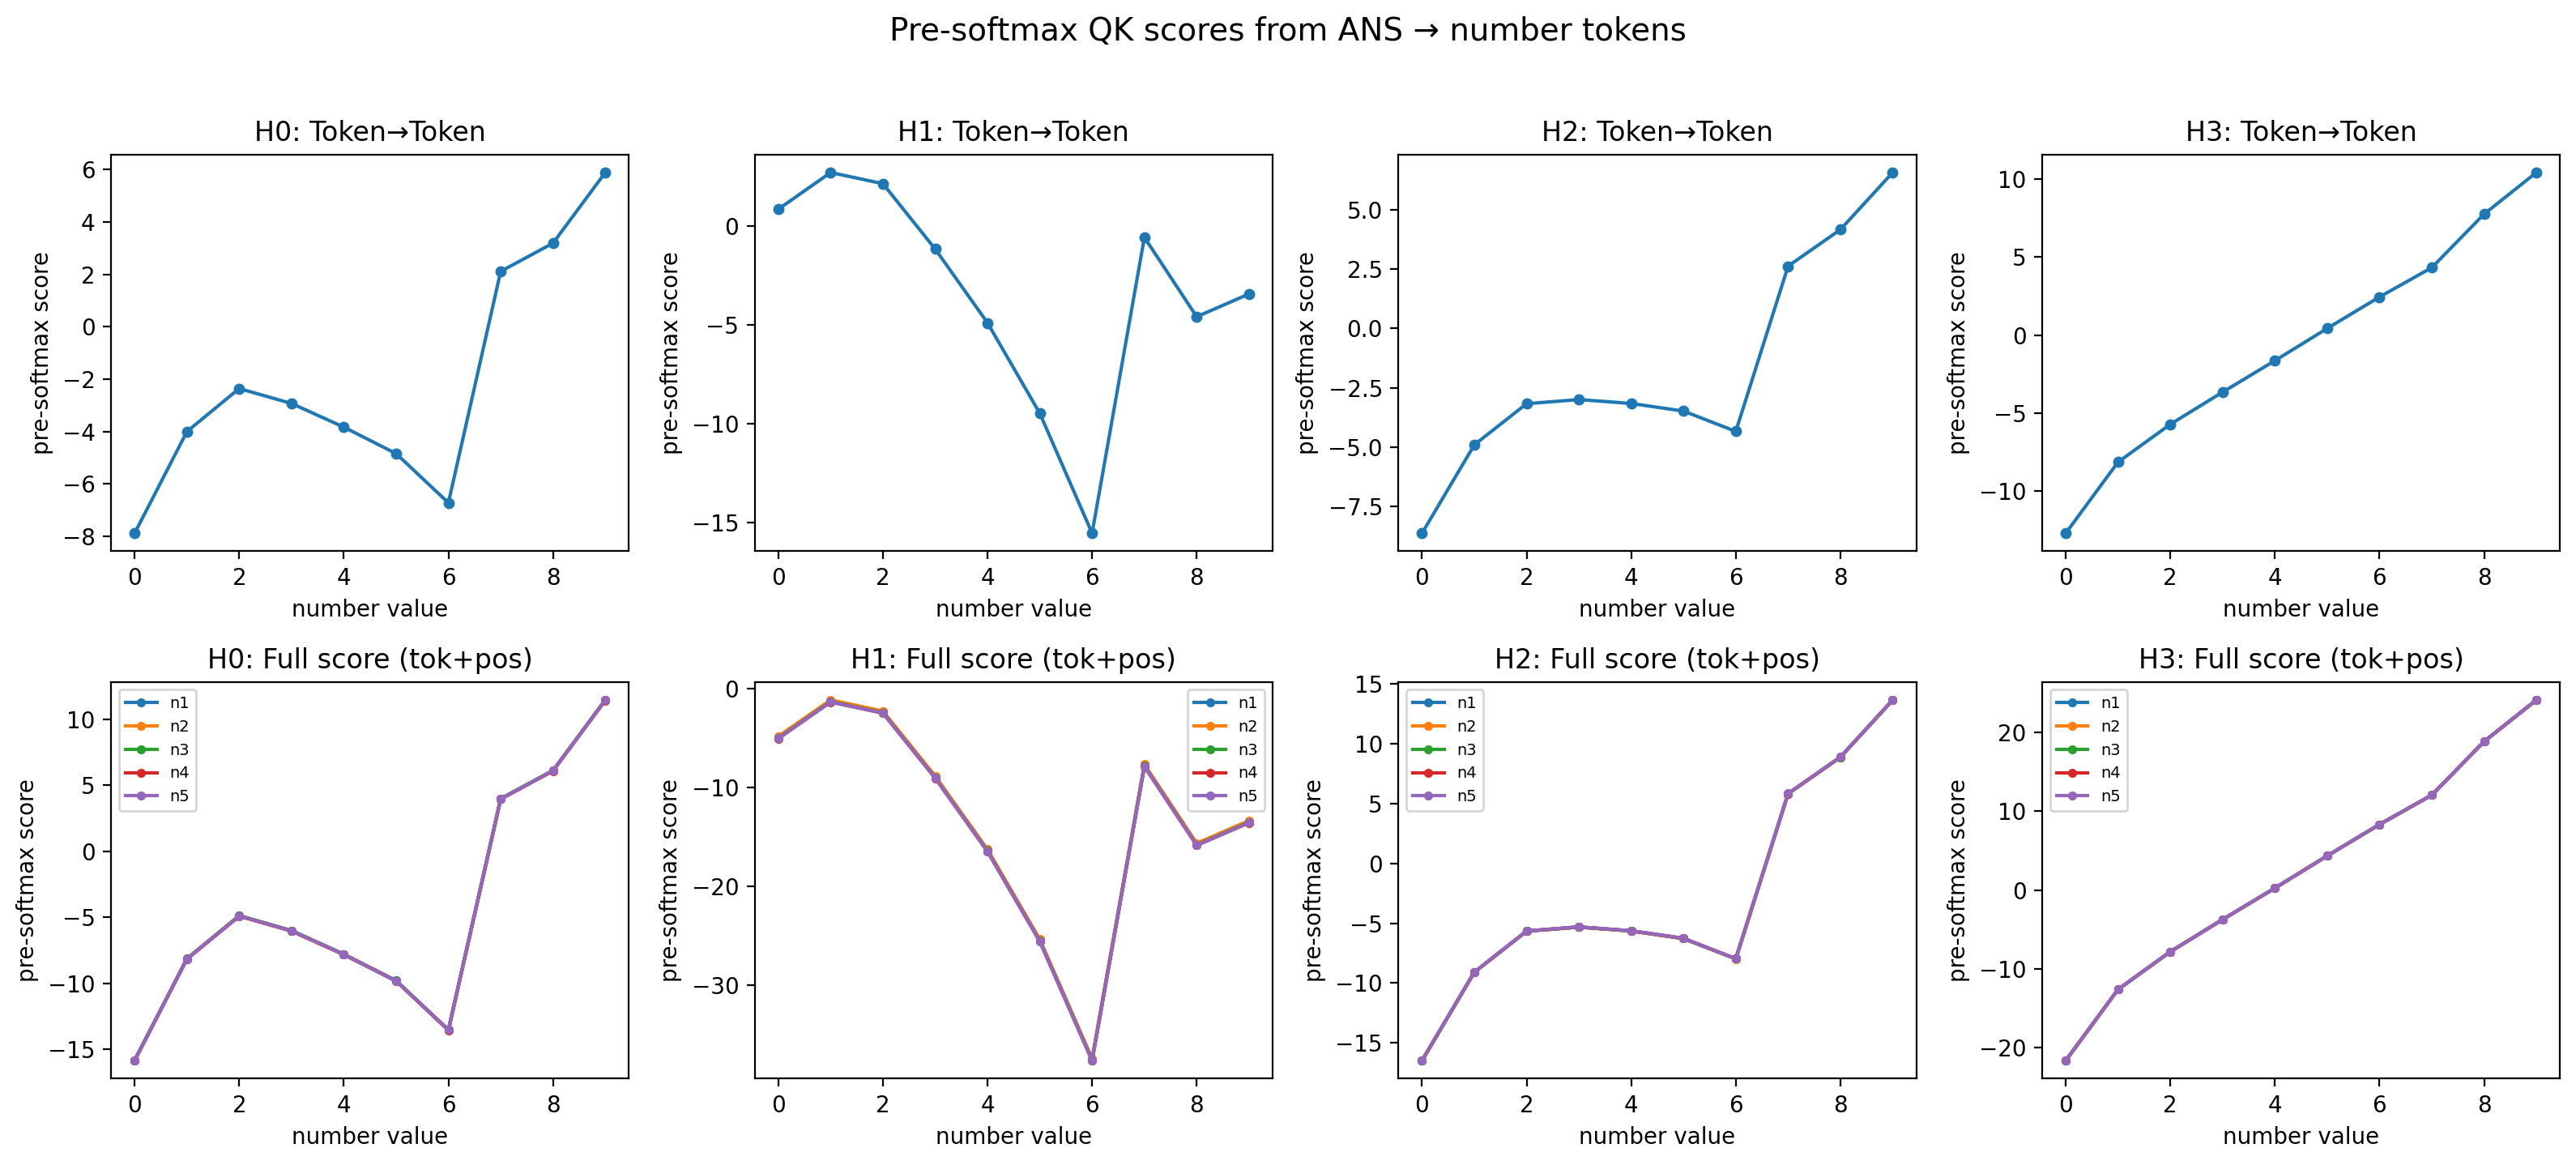

In [14]:
# ── Pre-softmax QK scores: decomposed into token-token, position-position, and cross terms ──
raw = raw_model_1
W_E = raw.tok_embed.weight.detach()   # (vocab_size=14, d_model=64)
W_P = raw.pos_embed.weight.detach()   # (max_seq_len=12, d_model=64)
d_head = 16

# ANS token index and position in the sequence [BOS, n1, SEP, n2, SEP, n3, SEP,n4, SEP, n5, ANS]
ans_tok = ANS_1         # token 12
ans_pos = 10            # position index of ANS in a 5-number sequence
num_tokens = list(range(NUM_RANGE_1))  # 0..9
num_positions = [1, 3, 5, 7, 9]       # positions of n1..n5 in the token sequence

fig, axes = plt.subplots(2, n_heads, figsize=(4 * n_heads, 7))

for h in range(n_heads):
    head = raw.layers[0].heads[h]
    W_Q = head.W_Q.weight.detach()  # (d_head, d_model)
    W_K = head.W_K.weight.detach()  # (d_head, d_model)
    scale = d_head ** 0.5

    # ── Row 1: Token-Token scores (ANS token → number tokens 0-9) ──
    # Ignores position: q = W_Q @ W_E[ANS], k = W_K @ W_E[num]
    q_ans_tok = W_Q @ W_E[ans_tok]
    scores_tok_tok = [(q_ans_tok @ (W_K @ W_E[n]) / scale).item() for n in num_tokens]

    axes[0][h].plot(num_tokens, scores_tok_tok, 'o-', markersize=4)
    axes[0][h].set_title(f"H{h}: Token→Token")
    axes[0][h].set_xlabel("number value")
    axes[0][h].set_ylabel("pre-softmax score")

    # ── Row 2: Full score (ANS → number n at each of the 5 positions) ──
    q_ans_full = W_Q @ (W_E[ans_tok] + W_P[ans_pos])
    for pi, pos in enumerate(num_positions):
        scores_full = [(q_ans_full @ (W_K @ (W_E[n] + W_P[pos])) / scale).item()
for n in num_tokens]
        axes[1][h].plot(num_tokens, scores_full, 'o-', markersize=3,
label=f"n{pi+1}")

    axes[1][h].set_title(f"H{h}: Full score (tok+pos)")
    axes[1][h].set_xlabel("number value")
    axes[1][h].set_ylabel("pre-softmax score")
    axes[1][h].legend(fontsize=7)

fig.suptitle("Pre-softmax QK scores from ANS → number tokens", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

The first plot, just shows how each input number (at some fixed position) is related to the `ANS` token. (the specific dip at around 6 could be due to training data)

The second plot on the bottom row, instead shows how the attention score varies based on the position of a number. We immediately see that the model really does not practically care about positions, as it should in this case: the max of single digits should be permutation invariant, and we should treat a list as just an unorder list, aka bag of numbers.

But most importantly, look at head 3 (H3). It turns out the model literally built a "number line" inside its high-dimensional embedding space!!

While the other lines are more difficult to interpret, head 3 clearly has learn a single direction. Look also at the scale of H3 (say from bottom plot): it goes from -20 to 20. Somehow symmetrically. It looks like what it would happen if I fix a direction, and let another one rotate.

##### How does the QK circuit produce a logit for each position that scales monotonically with the digit's value?

Remember that at `ANS` the score is given by:

$$A^{a}_{\text{ANS}j} = \vec{q}^{a}_{\text{ANS}}\cdot \vec{k}^{a}_j$$

One is fixed. The other one is varying. The observation is that we have in the beginning at 0 we are negative then we go to positive, to a more aligned direction with the query `ANS` vector as the numbers increase. 

The crazy thing is that all of this is happening in a high-dimensional space!


So, we need to look at:

$$k^{a}_j = W^{a}_K (W_E \vec{t}) $$


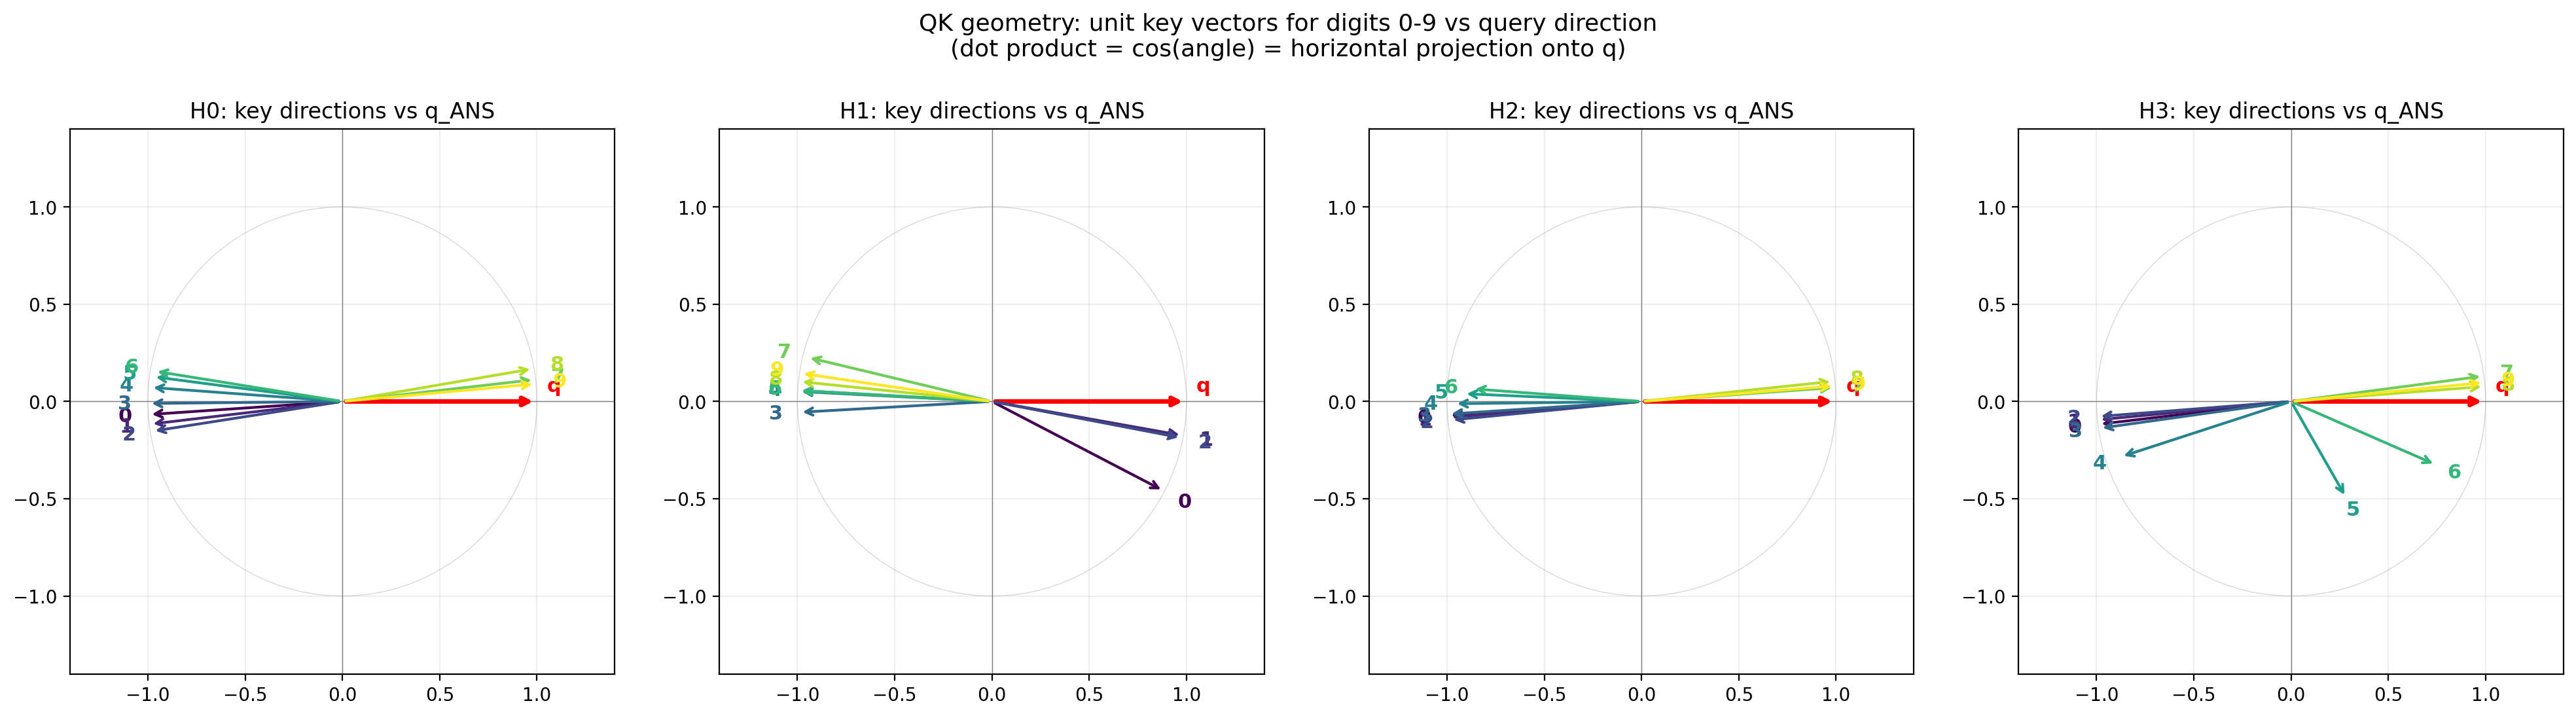

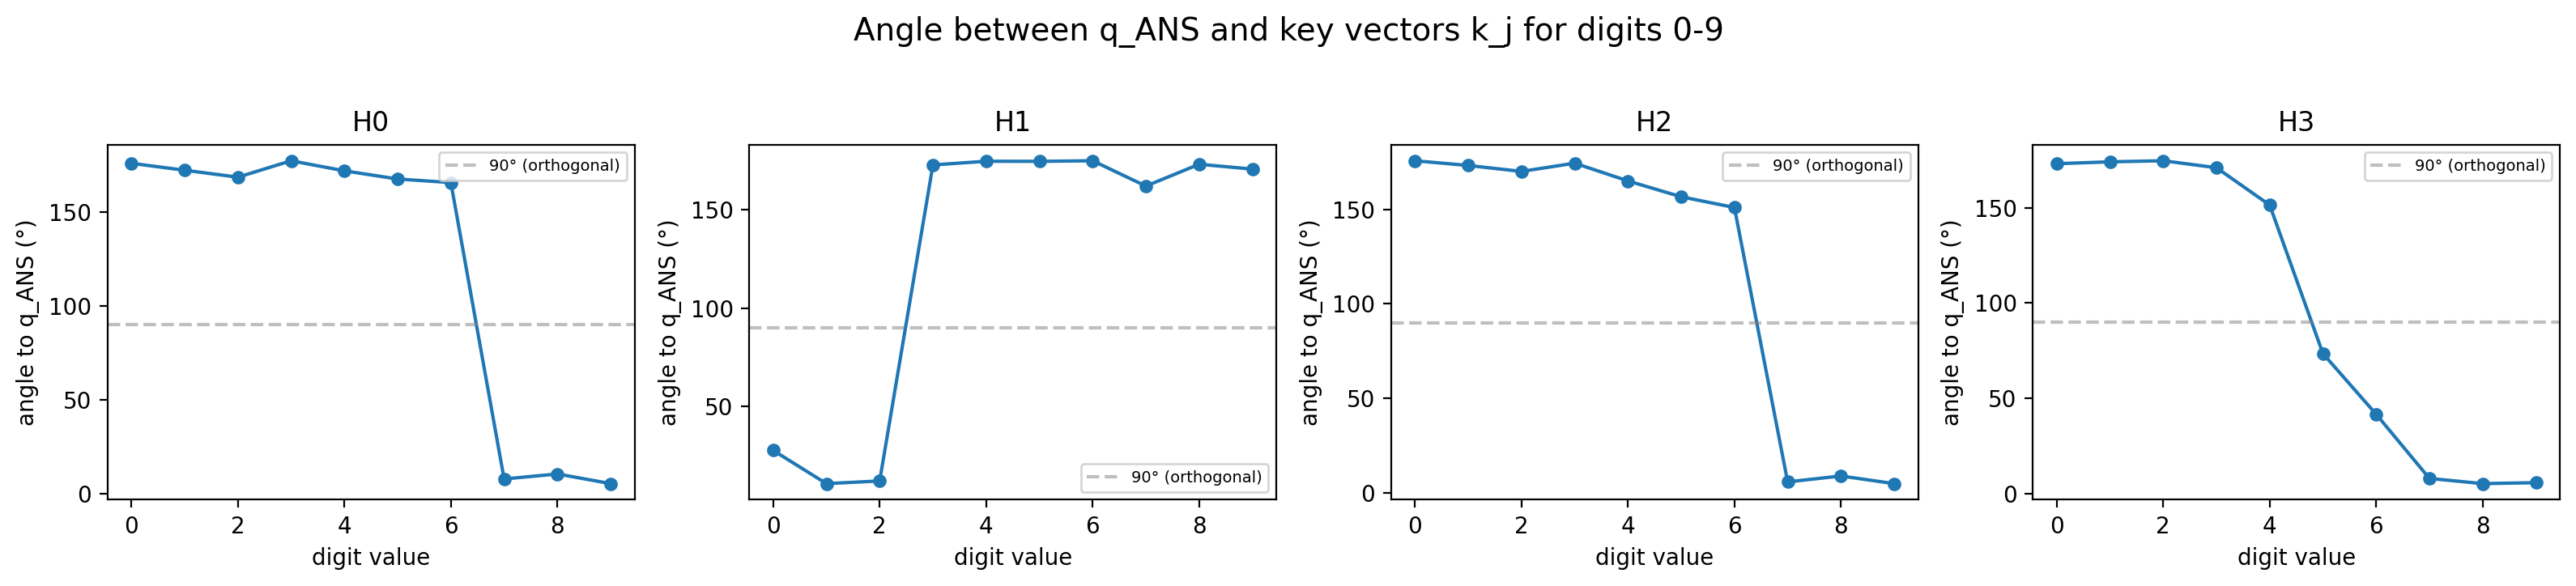

In [15]:
# ── Geometry of QK circuit: how do key vectors rotate relative to the query? ──
# All vectors normalized to unit length — we only care about angles.             
                                                                                    
W_E = raw_model_1.tok_embed.weight.detach().cpu()
W_P = raw_model_1.pos_embed.weight.detach().cpu()                                    
d_head = 16                                                
n_heads = 4                                                                          
ans_tok, ans_pos = ANS_1, 10                               

fig, axes = plt.subplots(1, n_heads, figsize=(5 * n_heads, 5))
cmap = plt.cm.viridis

for h in range(n_heads):
    head = raw_model_1.layers[0].heads[h]
    W_Q = head.W_Q.weight.detach().cpu()
    W_K = head.W_K.weight.detach().cpu()

    q = W_Q @ (W_E[ans_tok] + W_P[ans_pos])
    keys = torch.stack([W_K @ W_E[n] for n in range(NUM_RANGE_1)])

    # Normalize to unit vectors
    q_hat = q / q.norm()
    keys_hat = keys / keys.norm(dim=1, keepdim=True)

    # 2D basis: axis1 = q direction, axis2 = orthogonal spread
    spread = keys_hat[9] - keys_hat[0]
    spread_orth = spread - (spread @ q_hat) * q_hat
    if spread_orth.norm() > 1e-8:
        e2 = spread_orth / spread_orth.norm()
    else:
        e2 = torch.zeros_like(q_hat); e2[1] = 1.0

    # Project onto 2D
    q_2d = torch.tensor([q_hat @ q_hat, q_hat @ e2])  # always (1, 0)
    keys_2d = torch.stack([torch.tensor([k @ q_hat, k @ e2]) for k in keys_hat])

    ax = axes[h]

    # Draw unit circle for reference
    theta = np.linspace(0, 2 * np.pi, 100)
    ax.plot(np.cos(theta), np.sin(theta), 'grey', lw=0.5, alpha=0.3)

    # Query arrow
    ax.annotate('', xy=(q_2d[0].item(), q_2d[1].item()), xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color='red', lw=2.5))
    ax.text(q_2d[0].item() + 0.05, q_2d[1].item() + 0.05, 'q',
            color='red', fontsize=11, fontweight='bold')

    # Key arrows
    for j in range(NUM_RANGE_1):
        color = cmap(j / 9)
        ax.annotate('', xy=(keys_2d[j, 0].item(), keys_2d[j, 1].item()),
xytext=(0, 0),
                    arrowprops=dict(arrowstyle='->', color=color, lw=1.5))
        ax.text(keys_2d[j, 0].item() * 1.12, keys_2d[j, 1].item() * 1.12,
                str(j), color=color, fontsize=11, fontweight='bold',
                ha='center', va='center')

    ax.set_title(f"H{h}: key directions vs q_ANS")
    ax.set_xlim(-1.4, 1.4)
    ax.set_ylim(-1.4, 1.4)
    ax.set_aspect('equal')
    ax.axhline(0, color='grey', lw=0.5)
    ax.axvline(0, color='grey', lw=0.5)
    ax.grid(True, alpha=0.2)

fig.suptitle("QK geometry: unit key vectors for digits 0-9 vs query direction\n"
            "(dot product = cos(angle) = horizontal projection onto q)",
fontsize=13, y=1.04)
plt.tight_layout()
plt.show()


# ── Angle plot ──
fig2, axes2 = plt.subplots(1, n_heads, figsize=(4 * n_heads, 3.5))

for h in range(n_heads):
    head = raw_model_1.layers[0].heads[h]
    W_Q = head.W_Q.weight.detach().cpu()
    W_K = head.W_K.weight.detach().cpu()

    q = W_Q @ (W_E[ans_tok] + W_P[ans_pos])
    keys = torch.stack([W_K @ W_E[n] for n in range(NUM_RANGE_1)])

    cos_sim = torch.nn.functional.cosine_similarity(q.unsqueeze(0), keys, dim=1)
    angles_deg = torch.acos(cos_sim.clamp(-1, 1)) * 180 / np.pi

    axes2[h].plot(range(NUM_RANGE_1), angles_deg.numpy(), 'o-', markersize=5)
    axes2[h].set_title(f"H{h}")
    axes2[h].set_xlabel("digit value")
    axes2[h].set_ylabel("angle to q_ANS (°)")
    axes2[h].axhline(90, color='grey', linestyle='--', alpha=0.5, label='90° (orthogonal)')
    axes2[h].legend(fontsize=7)

fig2.suptitle("Angle between q_ANS and key vectors k_j for digits 0-9",
fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

H3 looks quite smooth!! Maybe a (inverted) sigmoid or cosine function?

Look at show each head tries to cluster numbers around some share direction.

/var/folders/2b/09l9dv1x4hqgb_dcgm8jgjcw0000gn/T/ipykernel_45581/2074683480.py:62: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, _ = curve_fit(step_model, digits, cos_sim, p0=p0,maxfev=10000)


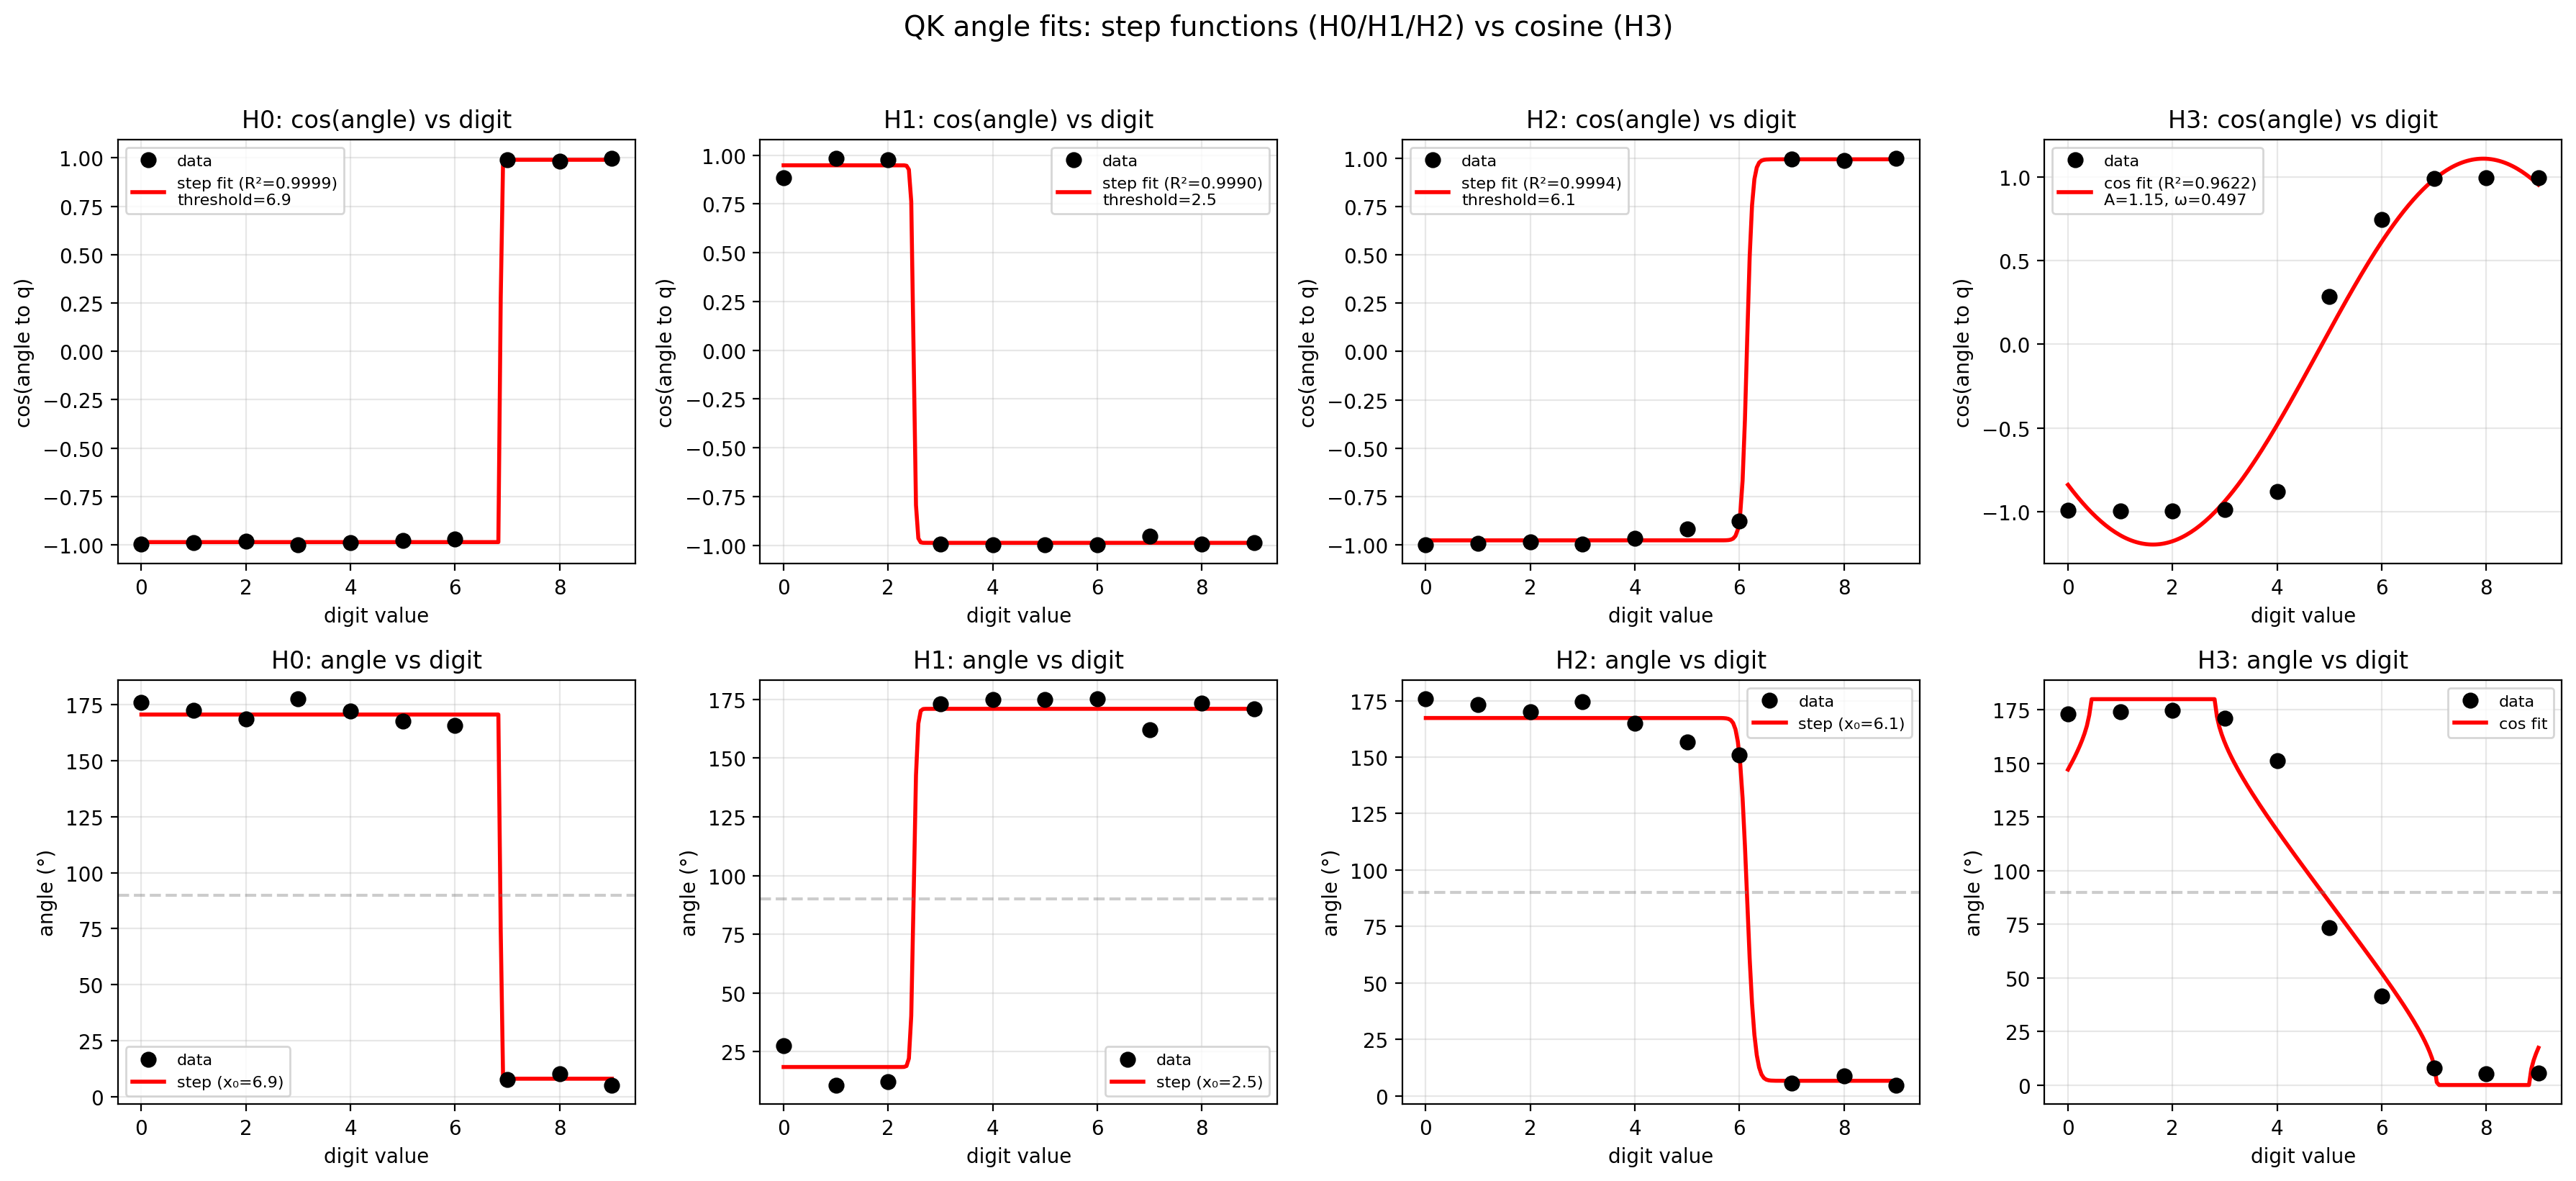

In [16]:
# ── Fitting QK angle relationships: step functions for H0/H1/H2, cosine for H3 ──                                                                                   
from scipy.optimize import curve_fit                                                 

W_E = raw_model_1.tok_embed.weight.detach().cpu()                                    
W_P = raw_model_1.pos_embed.weight.detach().cpu()
                                                                                    
fig, axes = plt.subplots(2, 4, figsize=(18, 8))            
digits = np.arange(NUM_RANGE_1)
digits_fine = np.linspace(0, 9, 200)

# Step function model: smoothed step (tanh-based)
def step_model(x, x0, a, lo, hi):
    """Smooth step: transitions from lo to hi at x0, steepness a."""
    return lo + (hi - lo) * (1 + np.tanh(a * (x - x0))) / 2

# Cosine model
def cos_model(x, A, omega, phi, C):
    return A * np.cos(omega * x + phi) + C

for h in range(4):
    head = raw_model_1.layers[0].heads[h]
    W_Q = head.W_Q.weight.detach().cpu()
    W_K = head.W_K.weight.detach().cpu()

    q = W_Q @ (W_E[ANS_1] + W_P[10])
    keys = torch.stack([W_K @ W_E[n] for n in range(NUM_RANGE_1)])

    cos_sim = torch.nn.functional.cosine_similarity(q.unsqueeze(0), keys, dim=1).numpy()
    angles = np.degrees(np.arccos(np.clip(cos_sim, -1, 1)))

    ax1 = axes[0][h]
    ax2 = axes[1][h]
    ax1.plot(digits, cos_sim, 'ko', markersize=7, label='data', zorder=5)
    ax2.plot(digits, angles, 'ko', markersize=7, label='data', zorder=5)

    if h == 3:
        # Cosine fit for H3
        try:
            p0 = [1.0, np.pi / 9, np.pi, 0.0]
            popt, _ = curve_fit(cos_model, digits, cos_sim, p0=p0, maxfev=10000)
            fit_vals = cos_model(digits_fine, *popt)
            ss_res = np.sum((cos_sim - cos_model(digits, *popt))**2)
            ss_tot = np.sum((cos_sim - cos_sim.mean())**2)
            r2 = 1 - ss_res / ss_tot

            ax1.plot(digits_fine, fit_vals, 'r-', lw=2,
                    label=f'cos fit (R²={r2:.4f})\nA={popt[0]:.2f}, ω={popt[1]:.3f}')
            # Angle space
            fit_angles = np.degrees(np.arccos(np.clip(fit_vals, -1, 1)))
            ax2.plot(digits_fine, fit_angles, 'r-', lw=2, label='cos fit')
        except Exception as e:
            print(f"H3 cos fit failed: {e}")
    else:
        # Step function fit for H0, H1, H2
        try:
            if h == 1:
                # H1 is inverted: high at 0, low elsewhere
                p0 = [0.5, -5.0, -1.0, 1.0]
            else:
                # H0, H2: low for small digits, high for large
                p0 = [7.0, 5.0, -1.0, 1.0]
            popt, _ = curve_fit(step_model, digits, cos_sim, p0=p0,maxfev=10000)
            fit_vals = step_model(digits_fine, *popt)
            ss_res = np.sum((cos_sim - step_model(digits, *popt))**2)
            ss_tot = np.sum((cos_sim - cos_sim.mean())**2)
            r2 = 1 - ss_res / ss_tot

            ax1.plot(digits_fine, fit_vals, 'r-', lw=2,
                    label=f'step fit (R²={r2:.4f})\nthreshold={popt[0]:.1f}')
            # Angle space
            fit_angles = np.degrees(np.arccos(np.clip(fit_vals, -1, 1)))
            ax2.plot(digits_fine, fit_angles, 'r-', lw=2, label=f'step (x₀={popt[0]:.1f})')
        except Exception as e:
            print(f"H{h} step fit failed: {e}")

    ax1.set_title(f"H{h}: cos(angle) vs digit")
    ax1.set_xlabel("digit value")
    ax1.set_ylabel("cos(angle to q)")
    ax1.legend(fontsize=8)
    ax1.grid(True, alpha=0.3)

    ax2.axhline(90, color='grey', linestyle='--', alpha=0.4)
    ax2.set_title(f"H{h}: angle vs digit")
    ax2.set_xlabel("digit value")
    ax2.set_ylabel("angle (°)")
    ax2.legend(fontsize=8)
    ax2.grid(True, alpha=0.3)

fig.suptitle("QK angle fits: step functions (H0/H1/H2) vs cosine (H3)",
fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

Super cool! To recap. All heads except H3 learn some sort of step function. So, maybe they are helping each other and making some sort of decision to classify which is the correct max. Then, H3 pins it down. 

Head 3 alone can not work, because we just have one direction with it, and we need to pin down another direction to interest some line.

This also explains previous ablation experiments where H3 alone was not sufficient. We also probably have, and we will see, that effectively the pre-softmax matrix is just a rank-1 matrix. So, each each is good at doing one and one thing only.

Clearly Head 3 learnt a number ordering in embedding space! It looks like we just have some line, of the sort $ax+b$, with $x$ our input number.

On the other hand, H1 does not look like it contributes to max-finding. 

Als, note how no matter the position we get always the same line!! So, the token value is doing the heavy lifting, as it should, and the neural network learnt a permutation invariant representation (as it should in this case).

However, while H3 is so clear, H0 and H2 are quite interesting in their shapes. They are also somehow monotonic, but with a decrease of the curve as we approach number 6.

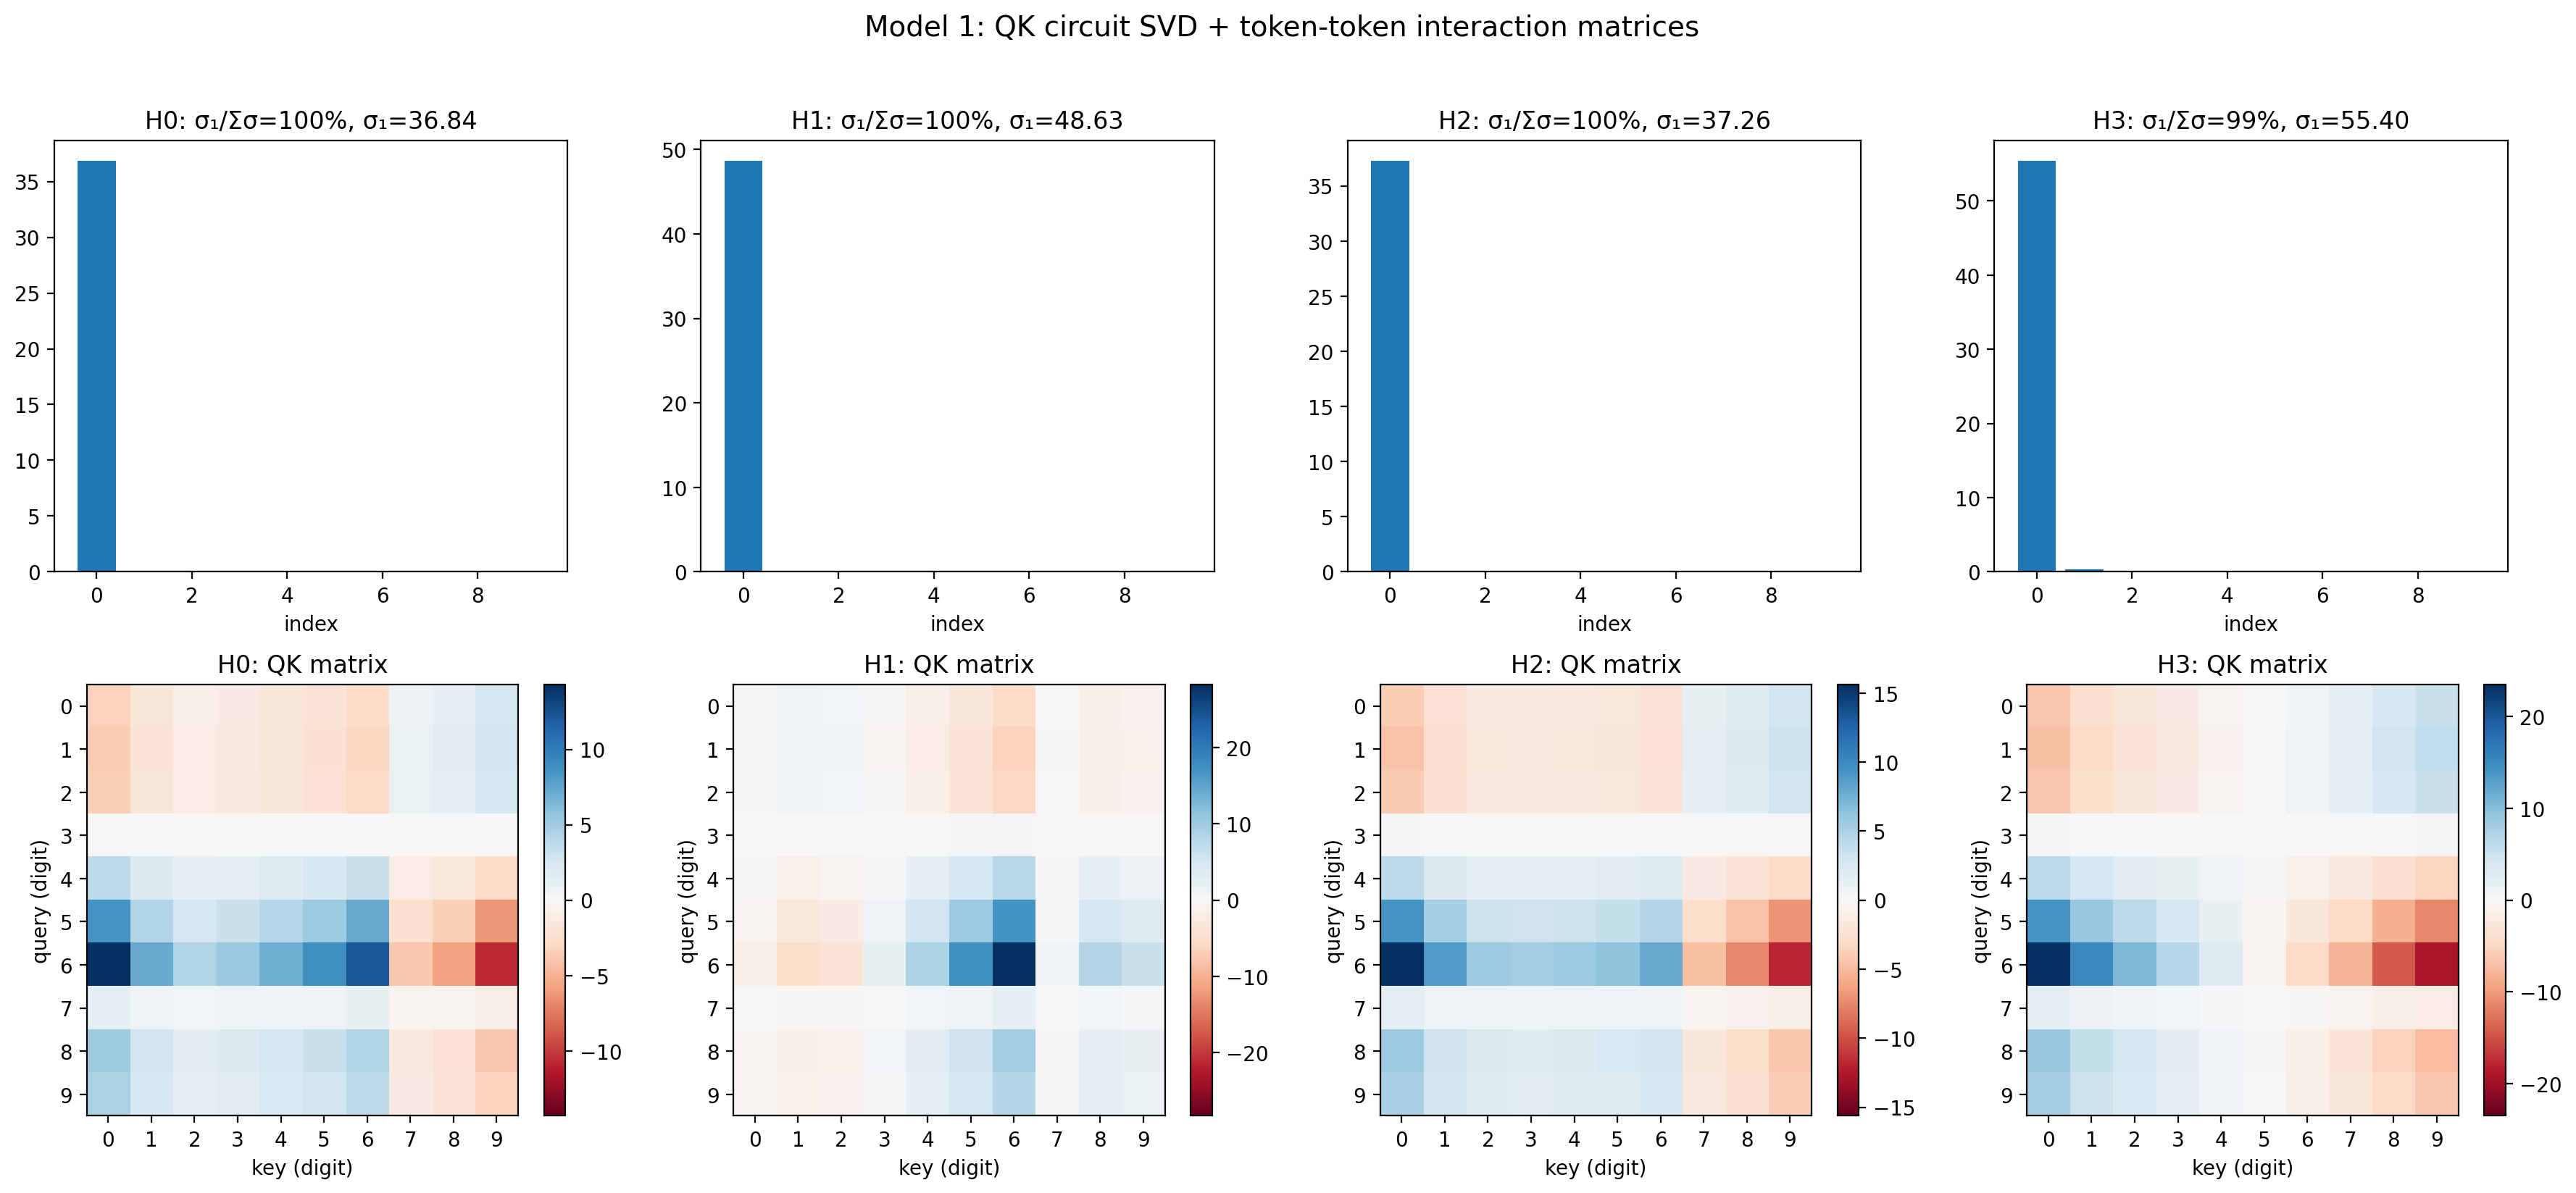

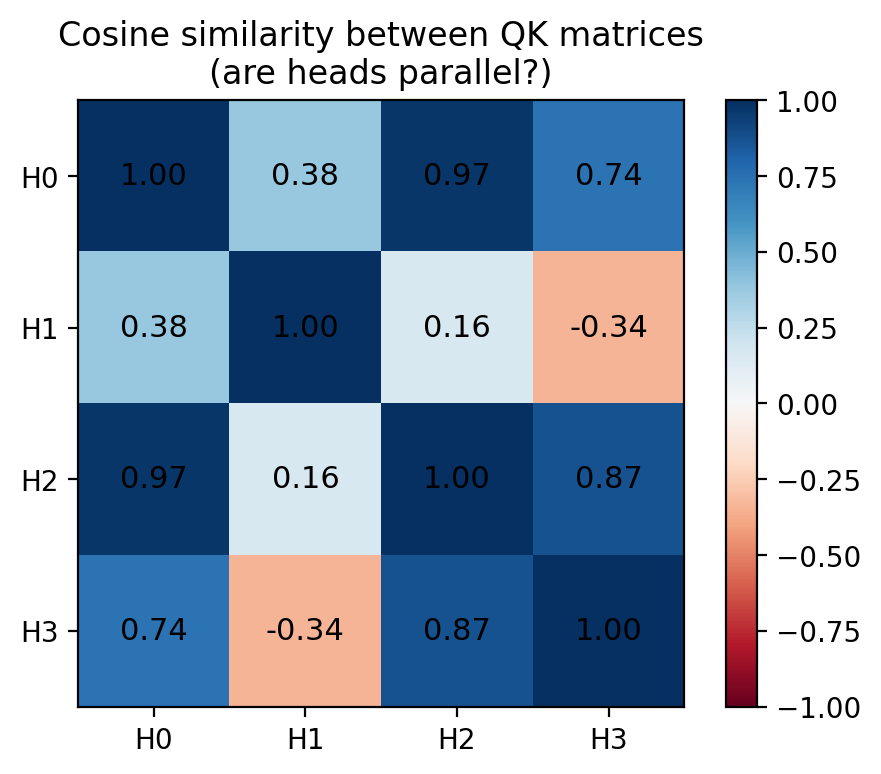

In [17]:
# ── QK circuit SVD + cosine similarity between heads (Model 1) ──
# QK matrix = W_E^T @ W_Q^T @ W_K @ W_E (10×10 digit submatrix)

W_E = raw_model_1.tok_embed.weight.detach().cpu()
d_head = 16
n_heads = 4

qk_directions = {}

fig, axes = plt.subplots(2, n_heads, figsize=(18, 8))

for h in range(n_heads):
    head = raw_model_1.layers[0].heads[h]
    W_Q = head.W_Q.weight.detach().cpu()
    W_K = head.W_K.weight.detach().cpu()

    QK = (W_E[:NUM_RANGE_1] @ W_Q.T @ W_K @ W_E[:NUM_RANGE_1].T / (d_head ** 0.5))
    U, S, Vt = torch.linalg.svd(QK)
    S_np = S.numpy()

    qk_directions[h] = QK.flatten().numpy()

    # Row 1: Singular values
    frac = S_np[0] / S_np.sum() * 100
    axes[0][h].bar(range(len(S_np)), S_np)
    axes[0][h].set_title(f"H{h}: σ₁/Σσ={frac:.0f}%, σ₁={S_np[0]:.2f}")
    axes[0][h].set_xlabel("index")

    # Row 2: QK heatmap
    QK_np = QK.numpy()
    vmax = abs(QK_np).max()
    im = axes[1][h].imshow(QK_np, cmap='RdBu', vmin=-vmax, vmax=vmax)
    axes[1][h].set_xticks(range(10))
    axes[1][h].set_yticks(range(10))
    axes[1][h].set_xlabel("key (digit)")
    axes[1][h].set_ylabel("query (digit)")
    axes[1][h].set_title(f"H{h}: QK matrix")
    plt.colorbar(im, ax=axes[1][h], fraction=0.046)

fig.suptitle("Model 1: QK circuit SVD + token-token interaction matrices", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


# ── Cosine similarity between QK directions ──
head_names = [f"H{h}" for h in range(n_heads)]
cos_matrix = np.zeros((n_heads, n_heads))

for i in range(n_heads):
    vi = qk_directions[i] / np.linalg.norm(qk_directions[i])
    for j in range(n_heads):
        vj = qk_directions[j] / np.linalg.norm(qk_directions[j])
        cos_matrix[i, j] = np.dot(vi, vj)

fig2, ax2 = plt.subplots(1, 1, figsize=(5, 4))
im = ax2.imshow(cos_matrix, cmap='RdBu', vmin=-1, vmax=1)
ax2.set_xticks(range(n_heads))
ax2.set_xticklabels(head_names)
ax2.set_yticks(range(n_heads))
ax2.set_yticklabels(head_names)

for i in range(n_heads):
    for j in range(n_heads):
        ax2.text(j, i, f"{cos_matrix[i,j]:.2f}", ha='center', va='center', fontsize=11)

plt.colorbar(im, ax=ax2, fraction=0.046)
ax2.set_title("Cosine similarity between QK matrices\n(are heads parallel?)")
plt.tight_layout()
plt.show()

We can see clearly that H3, H2 and H0 are quite parallel, and H1 has 'weak' alignment with the others (and a bit unaligned with H3, basically looking for smaller numbers?).

H0 and H2 are effectively the same.

Note that if they were perfectly parallel it would be more difficult to find the maximum. Having some sort of non-alignment I guess helps pinning down the maximum.

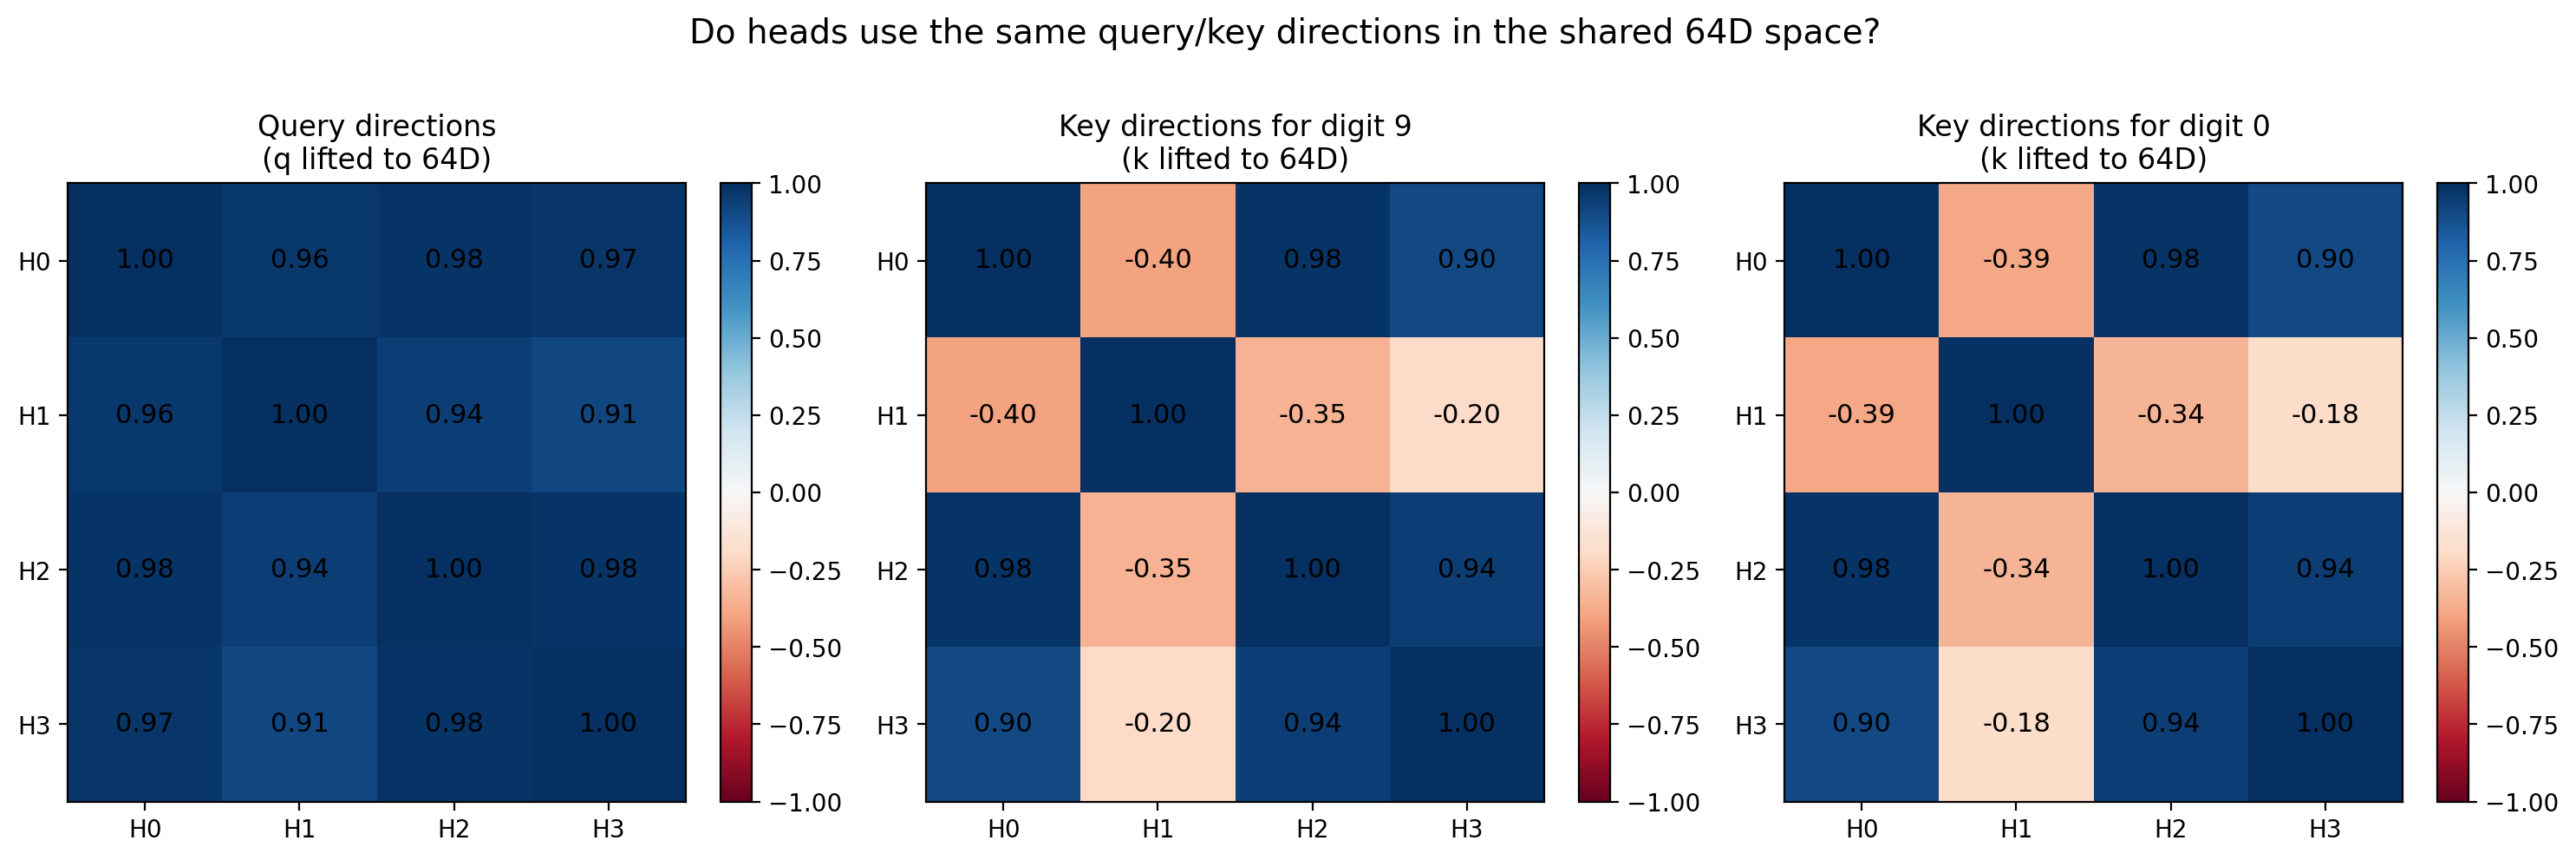

In [42]:
# ── Are the query/key directions the same across heads? ──
# Queries live in different 16D subspaces per head. To compare, we lift them
# back to the shared 64D embedding space: q_h^{64D} = W_Q^{hT} @ W_Q^h @ x_ANS

W_E = raw_model_1.tok_embed.weight.detach().cpu()
W_P = raw_model_1.pos_embed.weight.detach().cpu()
d_head = 16

x_ans = W_E[ANS_1] + W_P[10]  # shared input for all heads

# Lift queries to 64D
queries_64d = []
for h in range(4):
    W_Q = raw_model_1.layers[0].heads[h].W_Q.weight.detach().cpu()  # (16, 64)
    q_64 = W_Q.T @ W_Q @ x_ans  # (64,) — projection onto head's Q subspace
    queries_64d.append(q_64.numpy())

# Lift keys to 64D for a few digits
keys_64d = {d: [] for d in [0, 5, 9]}
for h in range(4):
    W_K = raw_model_1.layers[0].heads[h].W_K.weight.detach().cpu()
    for d in keys_64d:
        k_64 = W_K.T @ W_K @ W_E[d]
        keys_64d[d].append(k_64.numpy())

# Cosine similarities
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# Query cosine similarity
cos_q = np.zeros((4, 4))
for i in range(4):
    for j in range(4):
        cos_q[i, j] = np.dot(queries_64d[i], queries_64d[j]) / (
            np.linalg.norm(queries_64d[i]) * np.linalg.norm(queries_64d[j]))

ax = axes[0]
im = ax.imshow(cos_q, cmap='RdBu', vmin=-1, vmax=1)
ax.set_xticks(range(4)); ax.set_xticklabels([f"H{h}" for h in range(4)])
ax.set_yticks(range(4)); ax.set_yticklabels([f"H{h}" for h in range(4)])
for i in range(4):
    for j in range(4):
        ax.text(j, i, f"{cos_q[i,j]:.2f}", ha='center', va='center', fontsize=11)
plt.colorbar(im, ax=ax, fraction=0.046)
ax.set_title("Query directions\n(q lifted to 64D)")

# Key cosine similarity for digit 9
cos_k9 = np.zeros((4, 4))
for i in range(4):
    for j in range(4):
        cos_k9[i, j] = np.dot(keys_64d[9][i], keys_64d[9][j]) / (
            np.linalg.norm(keys_64d[9][i]) * np.linalg.norm(keys_64d[9][j]))

ax = axes[1]
im = ax.imshow(cos_k9, cmap='RdBu', vmin=-1, vmax=1)
ax.set_xticks(range(4)); ax.set_xticklabels([f"H{h}" for h in range(4)])
ax.set_yticks(range(4)); ax.set_yticklabels([f"H{h}" for h in range(4)])
for i in range(4):
    for j in range(4):
        ax.text(j, i, f"{cos_k9[i,j]:.2f}", ha='center', va='center', fontsize=11)
plt.colorbar(im, ax=ax, fraction=0.046)
ax.set_title("Key directions for digit 9\n(k lifted to 64D)")

# Key cosine similarity for digit 0
cos_k0 = np.zeros((4, 4))
for i in range(4):
    for j in range(4):
        cos_k0[i, j] = np.dot(keys_64d[0][i], keys_64d[0][j]) / (
            np.linalg.norm(keys_64d[0][i]) * np.linalg.norm(keys_64d[0][j]))

ax = axes[2]
im = ax.imshow(cos_k0, cmap='RdBu', vmin=-1, vmax=1)
ax.set_xticks(range(4)); ax.set_xticklabels([f"H{h}" for h in range(4)])
ax.set_yticks(range(4)); ax.set_yticklabels([f"H{h}" for h in range(4)])
for i in range(4):
    for j in range(4):
        ax.text(j, i, f"{cos_k0[i,j]:.2f}", ha='center', va='center', fontsize=11)
plt.colorbar(im, ax=ax, fraction=0.046)
ax.set_title("Key directions for digit 0\n(k lifted to 64D)")

fig.suptitle("Do heads use the same query/key directions in the shared 64D space?", fontsize=14, y=1.05)
plt.tight_layout()
plt.show()


Enough of QK attention stuff. Let's focus on the OV stuff now.

Ok. Now we know that heads help each other to pin down the max position. What about knowing its value?

### Looking at the OV circuit

Self-attention as a "null operation" / learned bias. When ANS attends to itself, the value vector is `W_V @ (W_E[ANS] + W_P[10])` — this contains no information about the input numbers. It's a fixed vector regardless of the input. So through the OV circuit, self-attention produces a constant additive bias to the logits. This is effectively the model's way of saying: "I have nothing useful to attend to, so I'll contribute a fixed default."

It looks like 0 is a bit weird.... Is this because we have direct path?

In [19]:
tokens = tokenize_1([0, 0, 0, 0, 0])
x = torch.tensor([tokens], device=device)
logits, _ = model_1(x)
# Softmax over number tokens at the ANS position (last token)
probs = torch.softmax(logits[0, -1, :NUM_RANGE_1], dim=-1).detach().cpu()
pred = probs.argmax().item()
pred

0

In [20]:
with torch.no_grad():                                                                   
    direct, head_contribs = decompose_logits(raw_model_1, tokenize_1([0,0,0,0,0]), device)
                                                                                        
for name, logits in [("Direct", direct)] + [(f"H{h}", head_contribs[h]) for h in          
range(4)]:                                                                                
    vals = logits[:NUM_RANGE_1].cpu()                                                     
    print(f"{name:8s}: argmax={vals.argmax().item()}, logits={[f'{v:.1f}' for v in        
vals.numpy()]}")                                                                          
                                                                                        
total = direct + sum(head_contribs)                                                       
print(f"{'Total':8s}: argmax={total[:NUM_RANGE_1].argmax().item()}")

Direct  : argmax=7, logits=['-2.2', '-1.0', '-0.1', '0.7', '1.3', '1.6', '1.4', '2.3', '1.9', '1.0']
H0      : argmax=3, logits=['17.1', '45.0', '56.0', '56.2', '43.6', '22.6', '-15.3', '32.2', '-3.1', '-39.9']
H1      : argmax=3, logits=['-4.0', '6.5', '12.2', '15.9', '14.8', '11.5', '1.9', '15.2', '6.3', '-4.3']
H2      : argmax=2, logits=['51.8', '68.3', '69.3', '59.1', '40.0', '9.6', '-15.5', '-14.8', '-37.6', '-59.7']
H3      : argmax=0, logits=['300.1', '231.7', '149.4', '51.8', '-46.8', '-131.4', '-202.0', '-121.5', '-186.5', '-181.5']
Total   : argmax=0


So the model learned the self-attention sink values specifically so that when all heads   
disengage (all numbers below threshold), the residual biases sum to favor small numbers.  
H3's self-attention bias alone is enough — 300 for digit 0 crushes the direct path's 2.3  
for digit 7.                                                                            

H3 is doing double duty. When it actively attends to a number, its OV    
circuit (σ=800) writes the "which number is the max" signal. When it self-attends (no good
number found), it writes a "the answer is probably 0" fallback. The model embedded its   
edge-case handling directly into the attention sink values.                             

So:                        

1. QK circuit: H3 (cosine) + H0/H2 (step functions) identify the largest number           
2. OV circuit: Rank-1 threshold voting copies the max to the output                     
3. Direct path: Weak baseline toward 7 (the statistical prior)                            
4. Self-attention sinks: When heads can't find useful numbers, they contribute fixed biases that favor small digits — correcting the direct path's bias toward 7               
                                                                            

When the sequence is [0, 0, 0, 0, 0], the entire network enters its "Null State":
The Direct Path shouts: "The answer is 7!"
H0 is "off" (parked on ANS), outputting a constant vector.
H1 is "off" (parked on ANS), outputting a constant vector.
H2 is "off" (parked on ANS), outputting a constant vector.
H3 is "off" (parked on ANS), outputting a constant vector.
Gradient descent perfectly balanced these weights so that when you add the Direct Path 7 to the constant "off" vectors of all four heads, the math perfectly cancels out to leave 0 as the highest logit.

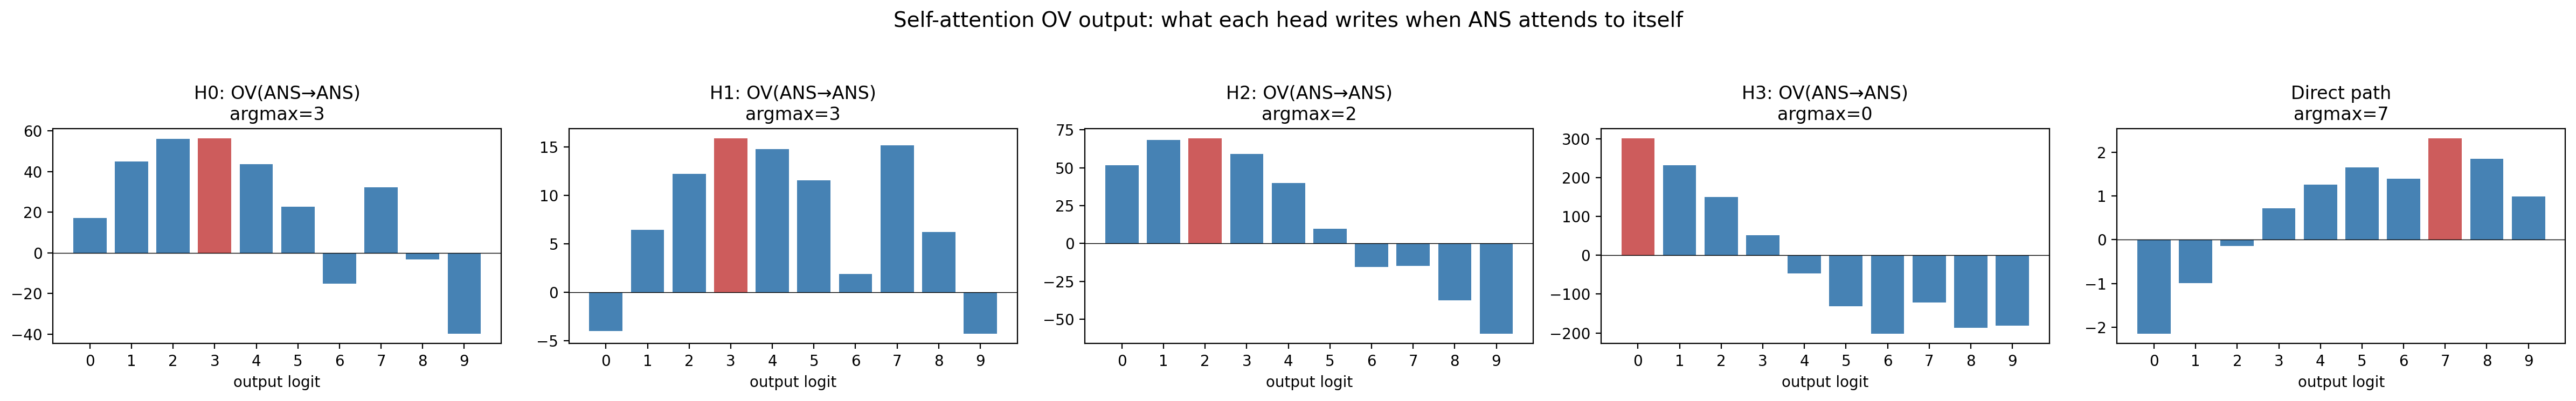

In [21]:
# ── Verify: what does each head's OV circuit output when attending to ANS itself? ──                                                                           
# This is the fixed bias each head contributes via self-attention.                   

W_E = raw_model_1.tok_embed.weight.detach()                                          
W_P = raw_model_1.pos_embed.weight.detach()                
W_U = raw_model_1.unembed.weight.detach()
W_O_full = raw_model_1.layers[0].W_O.weight.detach()
d_head = 16

# ANS embedding: what gets read when ANS attends to itself
x_ans = W_E[ANS_1] + W_P[10]

fig, axes = plt.subplots(1, 5, figsize=(24, 3.5))

for h in range(4):
    W_V_h = raw_model_1.layers[0].heads[h].W_V.weight.detach()
    W_O_h = W_O_full[:, h * d_head:(h + 1) * d_head]

    # OV output when attending to ANS: W_U @ W_O_h @ W_V_h @ x_ans
    ov_self = (W_U[:NUM_RANGE_1] @ W_O_h @ W_V_h @ x_ans).cpu().numpy()

    colors = ['indianred' if v == max(ov_self) else 'steelblue' for v in ov_self]
    axes[h].bar(range(NUM_RANGE_1), ov_self, color=colors)
    axes[h].set_xticks(range(NUM_RANGE_1))
    axes[h].set_xlabel("output logit")
    axes[h].set_title(f"H{h}: OV(ANS→ANS)\nargmax={ov_self.argmax()}")
    axes[h].axhline(0, color='black', lw=0.5)

# Also show direct path for comparison
direct = (W_U[:NUM_RANGE_1] @ x_ans).cpu().numpy()
colors = ['indianred' if v == max(direct) else 'steelblue' for v in direct]
axes[4].bar(range(NUM_RANGE_1), direct, color=colors)
axes[4].set_xticks(range(NUM_RANGE_1))
axes[4].set_xlabel("output logit")
axes[4].set_title(f"Direct path\nargmax={direct.argmax()}")
axes[4].axhline(0, color='black', lw=0.5)

fig.suptitle("Self-attention OV output: what each head writes when ANS attends to itself", fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

### And how does the model know which is the real number?

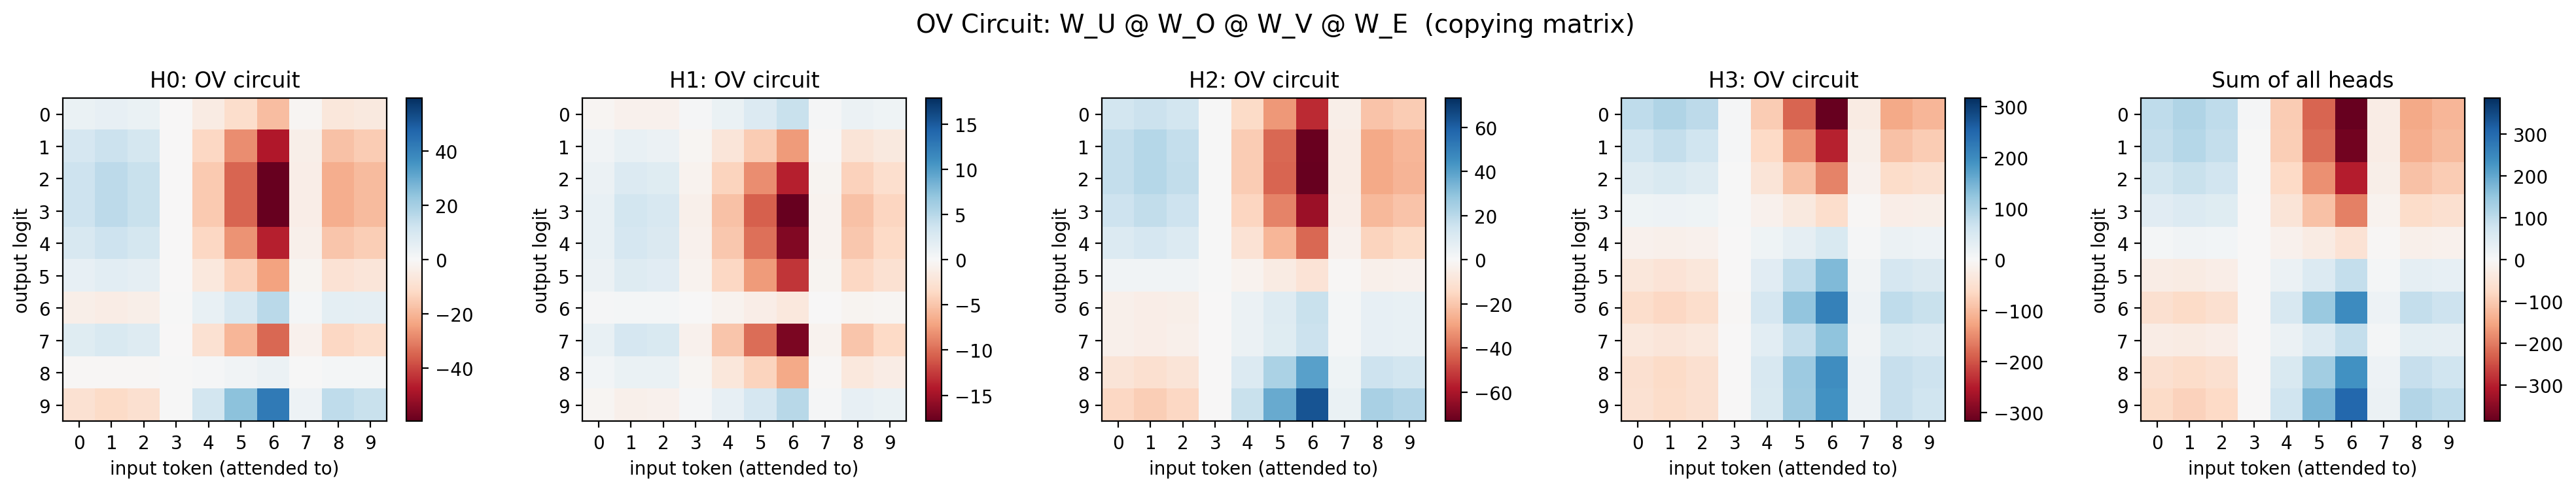

In [22]:
# ── OV Circuit: W_U @ W_O @ W_V @ W_E  (the "copying" matrix) ──
# For each head, this shows: if ANS attends to token t, how much does that           
# boost each output logit? A strong diagonal means "copy the attended token."        

W_E = raw_model_1.tok_embed.weight.detach()                                          
W_U = raw_model_1.unembed.weight.detach()              # (vocab_size=14,           d_model=64)
W_O_full = raw_model_1.layers[0].W_O.weight.detach()   # (d_model=64,d_model=64)
d_head = 16
n_heads = 4

fig, axes = plt.subplots(1, n_heads + 1, figsize=(4 * (n_heads + 1), 3.5))

ov_sum = torch.zeros(NUM_RANGE_1, NUM_RANGE_1)

for h in range(n_heads):
    W_V_h = raw_model_1.layers[0].heads[h].W_V.weight.detach()  # (d_head,d_model)
    # W_O projects from concatenated head outputs; slice for this head
    W_O_h = W_O_full[:, h * d_head:(h + 1) * d_head]            # (d_model,d_head)

    # Full OV circuit: W_U @ W_O_h @ W_V_h @ W_E^T → (output_logits,input_tokens)
    OV = W_U[:NUM_RANGE_1] @ W_O_h @ W_V_h @ W_E[:NUM_RANGE_1].T  # (10, 10)

    ov_sum += OV.cpu()
    OV_np = OV.cpu().numpy()
    vmax = abs(OV_np).max()

    im = axes[h].imshow(OV_np, cmap="RdBu", vmin=-vmax, vmax=vmax)
    axes[h].set_xticks(range(NUM_RANGE_1))
    axes[h].set_yticks(range(NUM_RANGE_1))
    axes[h].set_xlabel("input token (attended to)")
    axes[h].set_ylabel("output logit")
    axes[h].set_title(f"H{h}: OV circuit")
    plt.colorbar(im, ax=axes[h], fraction=0.046)

# Sum of all heads
ov_np = ov_sum.numpy()
vmax = abs(ov_np).max()
im = axes[n_heads].imshow(ov_np, cmap="RdBu", vmin=-vmax, vmax=vmax)
axes[n_heads].set_xticks(range(NUM_RANGE_1))
axes[n_heads].set_yticks(range(NUM_RANGE_1))
axes[n_heads].set_xlabel("input token (attended to)")
axes[n_heads].set_ylabel("output logit")
axes[n_heads].set_title("Sum of all heads")
plt.colorbar(im, ax=axes[n_heads], fraction=0.046)

fig.suptitle("OV Circuit: W_U @ W_O @ W_V @ W_E  (copying matrix)", fontsize=14,y=1.02)
plt.tight_layout()
plt.show()

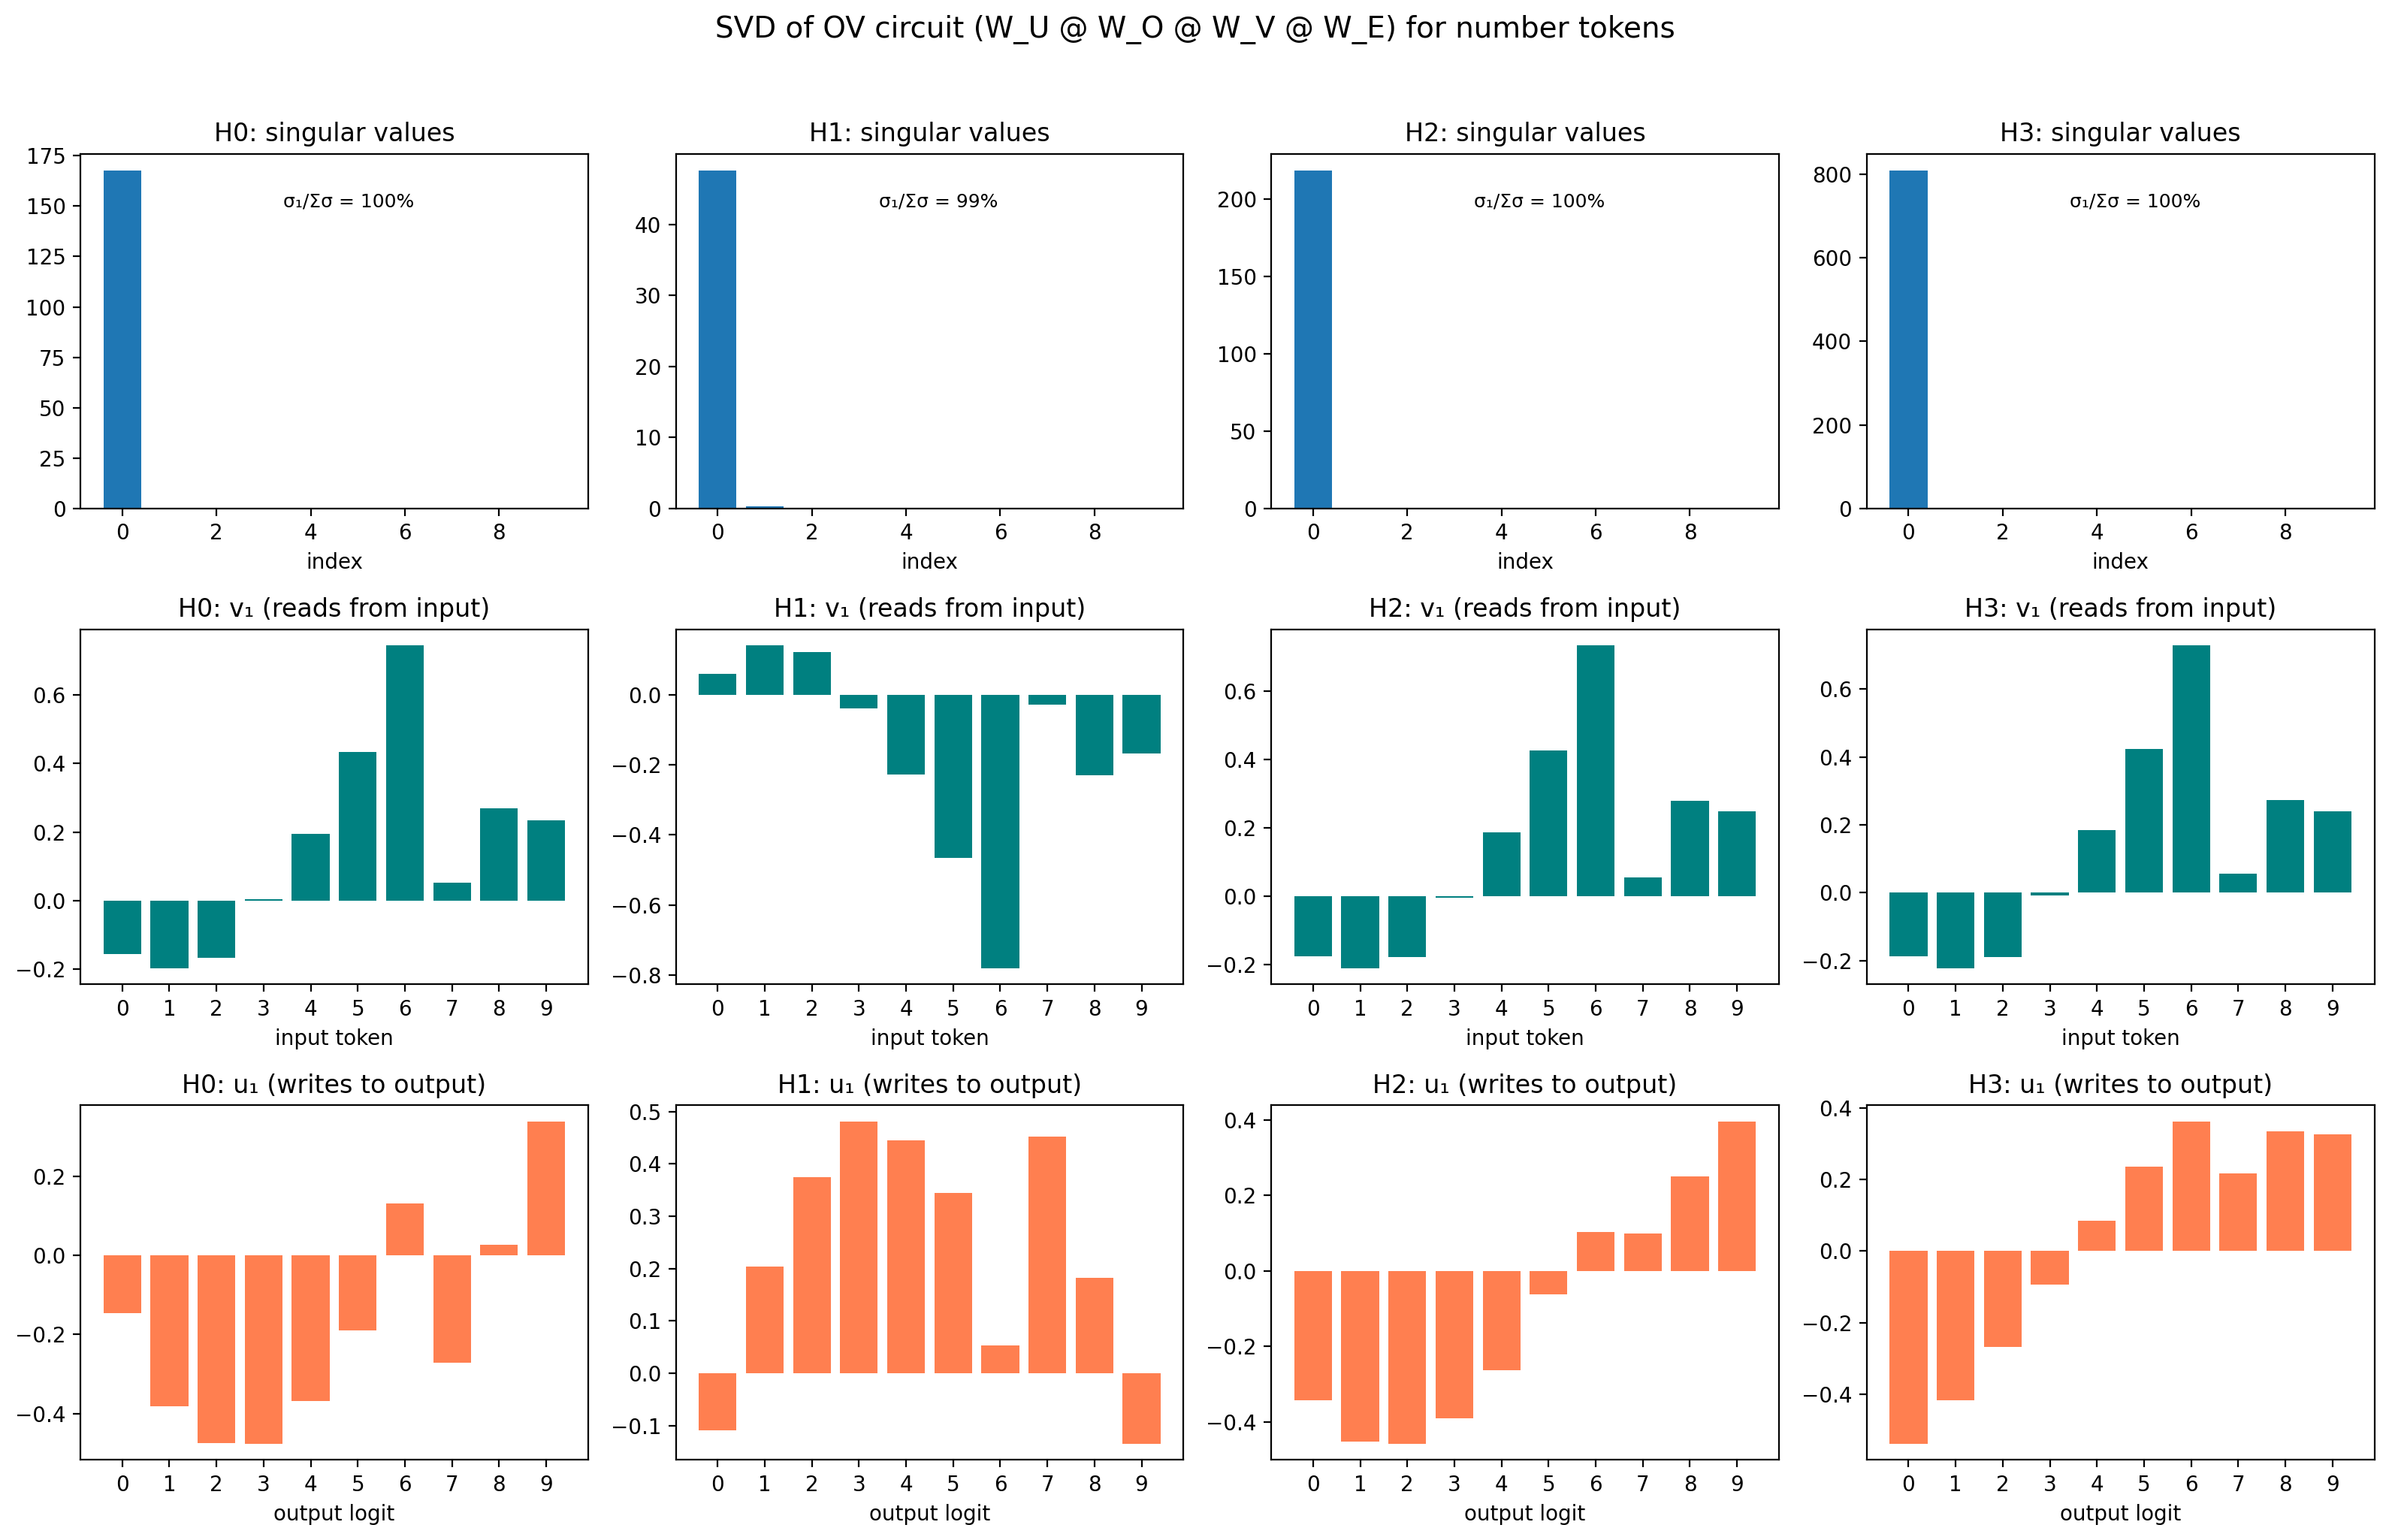

In [23]:
# ── SVD of the OV circuit: is it rank-1? What does it read/write? ──
# OV matrix = W_U @ W_O_h @ W_V_h @ W_E^T, shape (10, 10) for number tokens          
# SVD: OV = U @ diag(S) @ V^T                                                        
#   v_1 (right) = what the head "reads" from each input token
#   u_1 (left)  = what the head "writes" to each output logit                        
                                                                                    
W_E = raw_model_1.tok_embed.weight.detach()                                          
W_U = raw_model_1.unembed.weight.detach()                                          
W_O_full = raw_model_1.layers[0].W_O.weight.detach()
d_head = 16
n_heads = 4

fig, axes = plt.subplots(3, n_heads, figsize=(4 * n_heads, 10))

for h in range(n_heads):
    W_V_h = raw_model_1.layers[0].heads[h].W_V.weight.detach()
    W_O_h = W_O_full[:, h * d_head:(h + 1) * d_head]
    OV = (W_U[:NUM_RANGE_1] @ W_O_h @ W_V_h @ W_E[:NUM_RANGE_1].T).cpu()

    U, S, Vt = torch.linalg.svd(OV)
    S_np = S.numpy()

    # Row 1: Singular value spectrum
    axes[0][h].bar(range(len(S_np)), S_np)
    axes[0][h].set_title(f"H{h}: singular values")
    axes[0][h].set_xlabel("index")
    frac = S_np[0] / S_np.sum() * 100
    axes[0][h].annotate(f"σ₁/Σσ = {frac:.0f}%", xy=(0.4, 0.85),
                        xycoords='axes fraction', fontsize=9)

    # Row 2: v_1 (right singular vector) — what the head reads
    v1 = Vt[0].numpy()
    axes[1][h].bar(range(NUM_RANGE_1), v1, color='teal')
    axes[1][h].set_title(f"H{h}: v₁ (reads from input)")
    axes[1][h].set_xticks(range(NUM_RANGE_1))
    axes[1][h].set_xlabel("input token")

    # Row 3: u_1 (left singular vector) — what the head writes
    u1 = U[:, 0].numpy()
    axes[2][h].bar(range(NUM_RANGE_1), u1, color='coral')
    axes[2][h].set_title(f"H{h}: u₁ (writes to output)")
    axes[2][h].set_xticks(range(NUM_RANGE_1))
    axes[2][h].set_xlabel("output logit")

fig.suptitle("SVD of OV circuit (W_U @ W_O @ W_V @ W_E) for number tokens",
fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

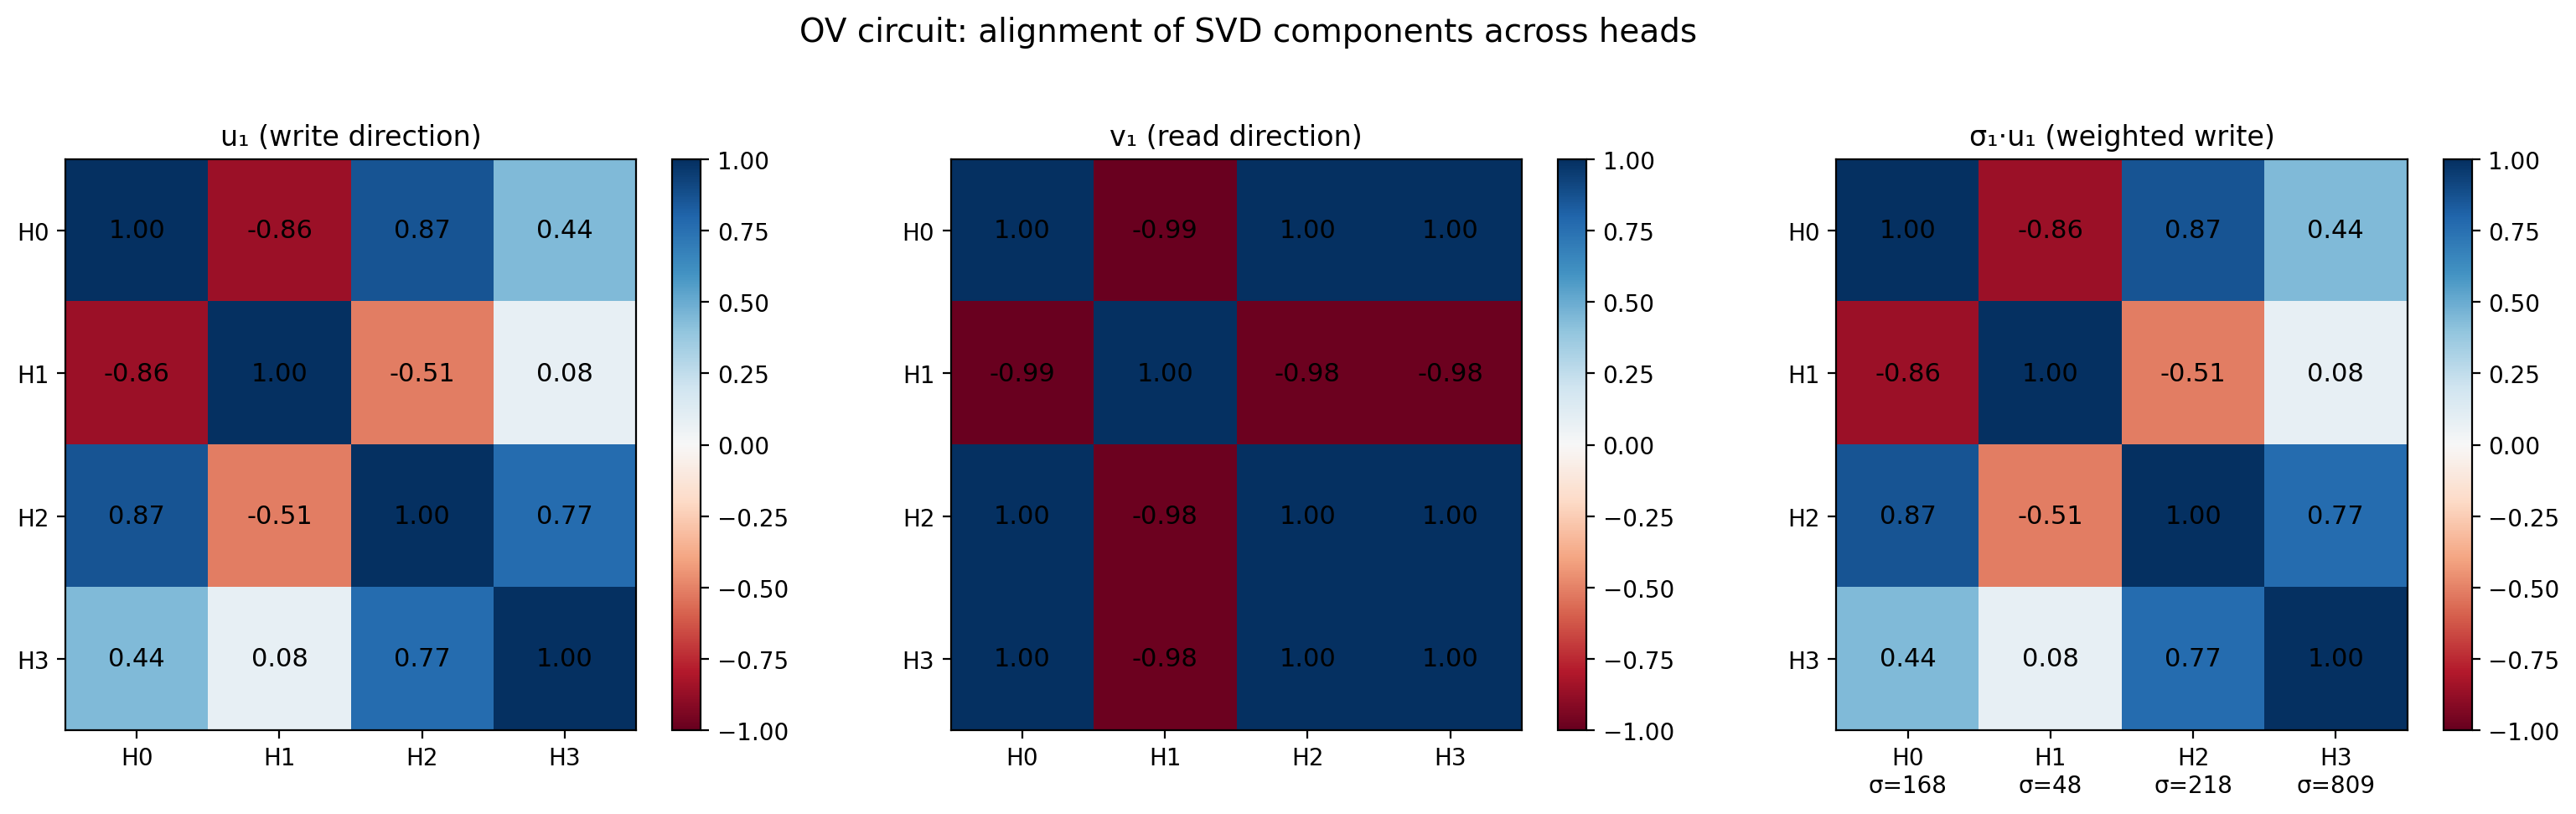


Summary:
  H0: σ₁=168
  H1: σ₁=48
  H2: σ₁=218
  H3: σ₁=809

u₁ cosines: H0·H2=0.87, H0·H3=0.44, H2·H3=0.77
v₁ cosines: H0·H2=1.00, H0·H3=1.00, H2·H3=1.00


In [24]:
# ── Alignment of OV SVD components across heads ──
# Are the u₁ (write) and v₁ (read) directions parallel or independent?

W_E = raw_model_1.tok_embed.weight.detach().cpu()
W_U = raw_model_1.unembed.weight.detach().cpu()
W_O_full = raw_model_1.layers[0].W_O.weight.detach().cpu()
d_head = 16
n_heads = 4

# Extract u₁, v₁, σ₁ for each head
u1s, v1s, s1s = [], [], []
for h in range(n_heads):
    W_V_h = raw_model_1.layers[0].heads[h].W_V.weight.detach().cpu()
    W_O_h = W_O_full[:, h * d_head:(h + 1) * d_head]
    OV = (W_U[:NUM_RANGE_1] @ W_O_h @ W_V_h @ W_E[:NUM_RANGE_1].T)
    U, S, Vt = torch.linalg.svd(OV)
    u1s.append(U[:, 0].numpy())
    v1s.append(Vt[0].numpy())
    s1s.append(S[0].item())

# Cosine similarity matrices
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for idx, (vecs, title) in enumerate([
    (u1s, "u₁ (write direction)"),
    (v1s, "v₁ (read direction)"),
]):
    cos = np.zeros((n_heads, n_heads))
    for i in range(n_heads):
        for j in range(n_heads):
            cos[i, j] = np.dot(vecs[i], vecs[j]) / (np.linalg.norm(vecs[i]) * np.linalg.norm(vecs[j]))

    ax = axes[idx]
    im = ax.imshow(cos, cmap='RdBu', vmin=-1, vmax=1)
    ax.set_xticks(range(n_heads))
    ax.set_xticklabels([f"H{h}" for h in range(n_heads)])
    ax.set_yticks(range(n_heads))
    ax.set_yticklabels([f"H{h}" for h in range(n_heads)])
    for i in range(n_heads):
        for j in range(n_heads):
            ax.text(j, i, f"{cos[i,j]:.2f}", ha='center', va='center', fontsize=11)
    plt.colorbar(im, ax=ax, fraction=0.046)
    ax.set_title(title)

# Also show σ₁-weighted u₁ cosine (since σ scales the contribution)
weighted_u1s = [s1s[h] * u1s[h] for h in range(n_heads)]
cos_w = np.zeros((n_heads, n_heads))
for i in range(n_heads):
    for j in range(n_heads):
        cos_w[i, j] = np.dot(weighted_u1s[i], weighted_u1s[j]) / (np.linalg.norm(weighted_u1s[i]) * np.linalg.norm(weighted_u1s[j]))
ax = axes[2]
im = ax.imshow(cos_w, cmap='RdBu', vmin=-1, vmax=1)
ax.set_xticks(range(n_heads))
ax.set_xticklabels([f"H{h}\nσ={s1s[h]:.0f}" for h in range(n_heads)])
ax.set_yticks(range(n_heads))
ax.set_yticklabels([f"H{h}" for h in range(n_heads)])
for i in range(n_heads):
    for j in range(n_heads):
        ax.text(j, i, f"{cos_w[i,j]:.2f}", ha='center', va='center', fontsize=11)
plt.colorbar(im, ax=ax, fraction=0.046)
ax.set_title("σ₁·u₁ (weighted write)")

fig.suptitle("OV circuit: alignment of SVD components across heads", fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

# Print summary
print("\nSummary:")
for h in range(n_heads):
    print(f"  H{h}: σ₁={s1s[h]:.0f}")
print(f"\nu₁ cosines: H0·H2={np.dot(u1s[0],u1s[2]):.2f}, H0·H3={np.dot(u1s[0],u1s[3]):.2f}, H2·H3={np.dot(u1s[2],u1s[3]):.2f}")
print(f"v₁ cosines: H0·H2={np.dot(v1s[0],v1s[2]):.2f}, H0·H3={np.dot(v1s[0],v1s[3]):.2f}, H2·H3={np.dot(v1s[2],v1s[3]):.2f}")

Heads are reading similar concepts from the input (I guess how big is a digit), but writing differently! Also, note again how dominant is the head number 3.

Hence, we can write

$\mathrm{logits} = \sum_h \sigma_h · f(\mathrm{digit}) · \vec{u}_h$

where $f(\mathrm{digit}) = \vec{v}_1 \cdot embedding(\mathrm{digit})$ is the same scalar function for all heads that are not H1 (because $v_1$ is shared), but the activation function's shape differs per head (step vs cosine, different thresholds).

#### Concluding Model 1a

The model finds the max via QK monotonicity, writes the answer via shared-readout OV voting, and handles edge cases through self-attention sinks.

## Model 1b

I did not have time to fully reverse-engineer Model 1b, but preliminary exploration revealed the following structure.

### Architecture and task

Model 1b is a **2-layer, 4-head** attention-only transformer finding the max of five numbers in 0--99. Each number is tokenized as two
digits (tens, ones), so the input sequence is `[BOS, t1, o1, SEP, t2, o2, ..., t5, o5, ANS]` (16 tokens). The model predicts **two
output tokens**: first the tens digit of the max, then the ones digit.

### Division of labor between layers

**Ablation results** reveal a clear split:

| Head removed | Tens acc. | Ones acc. | Role |
|---|---|---|---|
| None | 100% | 100% | — |
| L0H1 | 13% | 23% | **Primary tens-digit max finder** |
| L0H3 | 53% | 8% | **Critical for ones** (not tens) |
| L1H0 | 46% | 10% | **Critical for ones output** |
| L1H3 | 10% | 19% | **Critical for tens output** |
| All L0 | 37% | 13% | Both layers needed |
| All L1 | 9% | 8% | Both layers needed |

The asymmetry of **L0H3** is striking: removing it barely affects tens (53%) but destroys ones (8%). This head is not finding the
max, it is **gathering ones-digit information** that Layer 1 later reads.

### Composition: how layers talk to each other

Composition scores (Frobenius norm of $W_X^{L1} W_O^{L0}$ products) identify the information pathways:

- **Q-composition**: L1H0 $\leftarrow$ L0H1 (0.44), L1H3 $\leftarrow$ L0H1 (0.38). L0H1's max-finding signal shapes what L1 heads *ask
for*.
- **K-composition**: L1H0 $\leftarrow$ L0H3 (0.42), L1H3 $\leftarrow$ L0H3 (0.45). L0H3's gathered information shapes what L1 heads
*match against*.

### The two-phase algorithm

**Phase 1 (Layer 0)**:
- **L0H1** compares tens digits across positions. Its QK circuit shows monotonically increasing pre-softmax scores with digit value
(same mechanism as Model 1a). It marks which position holds the largest tens digit.
- **L0H3** gathers ones-digit information and writes it into the residual stream for Layer 1 to read.

**Phase 2 (Layer 1)**:
- **L1H3** uses L0H1's signal (via Q-composition) to output the correct tens digit at the ANS position.
- **L1H0** uses L0H3's gathered info (via K-composition) to attend to the correct number's position and output the ones digit.

### Composed attention $A^{(21)}$

The logit decomposition for two layers includes a composed term:

$$W_U \sum_{h \in H_2} \sum_{h' \in H_1} W_{O_h}^{(2)} W_{V_h}^{(2)} W_{O_{h'}}^{(1)} W_{V_{h'}}^{(1)} \sum_k A^{(21)}_{hh',ik}
x_k^{(0)}$$

where $A^{(21)}_{hh',ik} = \sum_j A^{(2)}_{h,ij} A^{(1)}_{h',jk}$ is the composed attention implementing a two-hop lookup.
Empirically, the composed attention from ANS+1 (ones prediction position) through L1H0/L1H3 $\leftarrow$ L0H1/L0H3 concentrates on the
ones digit of the number with the largest tens digit.

### What I would have explored further

- **OV circuit analysis** for both layers: does it copy digits or use threshold voting like Model 1a?
- **Same-tens-digit cases** (e.g. [53, 57, 51, 59, 55]): how does the model break ties when tens digits are equal?
- **Deeper composed QK analysis**: the effective Layer 1 QK scores (after L0 composition) to see exactly how L0's output modifies L1's
attention.
- **The role of positional embeddings**: how does the model know that two adjacent tokens (tens, ones) belong to the same number?


I found several things are still mainly rank-1, and my guess some induction head is at work here.
